# Analyze and plot results for networks performance

This script takes in the results from data-overview.ipynb, and performs analyses on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
from celluloid import Camera
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

## 0. Load data and build datasets

In [2]:
# Load data from 2nd infections
infection_type = 'prim'
reg_model = ''
runs = '-1-'
comment = "prim-Nact-Ediv-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'
#d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/std/processed_data'+runs+'runs'+'-'+comment+'.pkl'


clustered_mean_df = pd.read_pickle(d_mean)
#std_df = pd.read_pickle(d_std)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Nact_I,psi_Nact_H,psi_Nact_IH,F0_Nact,psi_NM_I,psi_NM_H,psi_NM_IH,F0_NM,psi_EM_I,psi_EM_H,psi_EM_IH,F0_EM,psi_Ediv_I,psi_Ediv_H,psi_Ediv_IH,F0_Ediv,harm_pI,T_min_pI,harm_pS,init_M,T_max_pI,T_pE_start,T_pE_max,int_pE,peff_protection,peff_toxicity,peff_utility,high_putility,high_pprotection,high_ptoxicity,high_pmemory,low_clear_timing,low_resp_timing,low_resp_end_timing,high_presponse
0,7.500000e-08,0.1,10000.0,1000.0,10000000.0,100.0,0.01,5000.0,-2.0,-2.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,-2.0,1.021226e+07,0.0,0.000000,0.0,17.563,0.00000,0.000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0,1,0,0
512,7.500000e-08,0.1,10000.0,1000.0,10000000.0,100.0,0.01,5000.0,-2.0,-2.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,-1.0,1.021226e+07,0.0,0.000000,0.0,17.563,0.00000,0.000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0,1,0,0
1024,7.500000e-08,0.1,10000.0,1000.0,10000000.0,100.0,0.01,5000.0,-2.0,-2.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,0.0,1.021226e+07,0.0,0.000000,0.0,17.563,0.00000,0.000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0,1,0,0
1536,7.500000e-08,0.1,10000.0,1000.0,10000000.0,100.0,0.01,5000.0,-2.0,-2.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,1.0,1.021226e+07,0.0,0.192009,0.0,17.563,0.20202,20.202,3.220,2.470301e-07,9.143278e-08,1.555973e-07,0,0,0,0,0,0,0,0
2048,7.500000e-08,0.1,10000.0,1000.0,10000000.0,100.0,0.01,5000.0,-2.0,-2.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-2.0,0.0,2.0,1.021226e+07,0.0,0.000000,0.0,17.563,0.00000,0.000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35953151,1.500000e-07,0.5,1000000.0,1000.0,10000000.0,100.0,0.01,5000.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,-2.0,8.651796e+06,0.0,141197.867563,10490.0,9.597,6.74597,14.812,558228.034,5.796308e-01,6.723708e-02,5.123937e-01,0,0,0,0,0,0,0,0
35953663,1.500000e-07,0.5,1000000.0,1000.0,10000000.0,100.0,0.01,5000.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,-1.0,8.341196e+06,0.0,204931.317094,12308.0,9.926,6.27746,11.991,631708.385,7.275354e-01,9.758634e-02,6.299491e-01,0,0,0,0,0,0,0,0
35954175,1.500000e-07,0.5,1000000.0,1000.0,10000000.0,100.0,0.01,5000.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,7.773006e+06,0.0,290670.551600,14662.0,10.178,6.81373,12.306,714579.719,9.981020e-01,1.384145e-01,8.596875e-01,0,0,0,0,0,0,0,0
35954687,1.500000e-07,0.5,1000000.0,1000.0,10000000.0,100.0,0.01,5000.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,1.0,7.816450e+06,0.0,430640.908311,46795.0,12.145,7.86408,14.280,870688.560,9.774143e-01,2.050671e-01,7.723472e-01,0,0,0,1,0,0,0,0


## 1. Performance-based evaluation of immune networks

In [3]:
# helper variables
vir_vars = ['d_I', 'K_IE', 'b_I', 'S_0']
virs = np.unique(clustered_mean_df[['d_I','K_IE', 'b_I']].to_numpy(), axis = 0) #vir_prop[:, 0:2]
n_virs = len(virs)

In [44]:
# Create additional variables
module_reg = {'Nact': Nact_reg, 'NM': NM_reg, 'EM': EM_reg, 'Ediv': Ediv_reg}
module_reg_labels = {'Nact': param_names[-16:-12], 'NM': param_names[-12:-8], 'EM': param_names[-8:-4], 'Ediv': param_names[-4:]}

if "full-reg" in comment:
    reg = Nact_reg + NM_reg + EM_reg + Ediv_reg
    reg_label = param_names[-len(reg):]
    modules = ['Nact', 'NM', 'EM', 'Ediv']
    reg_or = [Nact_reg[0:2]] + [NM_reg[0:2]] + [EM_reg[0:2]] + [Ediv_reg[0:2]]
    reg_and = [Nact_reg[2]] + [NM_reg[2]] + [EM_reg[2]] + [Ediv_reg[2]]
    reg_and_label = [param_names[-14]] + [param_names[-10]] + [param_names[-6]] + [param_names[-2]]
    reg_bias = [Nact_reg[3]] + [NM_reg[3]] + [EM_reg[3]] + [Ediv_reg[3]]
    reg_bias_label = [param_names[-13]] + [param_names[-9]] + [param_names[-5]] + [param_names[-1]]
else:
    reg = (Nact_reg if "Nact" in comment else []) + (NM_reg if "NM" in comment else []) + (EM_reg if "EM" in comment else []) + (Ediv_reg if "Ediv" in comment else [])
    reg_label = (param_names[-16:-12] if "Nact" in comment else []) + (param_names[-12:-8] if "NM" in comment else []) + (param_names[-8:-4] if "EM" in comment else []) + (param_names[-4:] if "Ediv" in comment else [])
    modules = (["Nact"] if "Nact" in comment else []) + (["NM"] if "NM" in comment else []) + (["EM"] if "EM" in comment else []) + (["Ediv"] if "Ediv" in comment else [])
    reg_or = (Nact_reg[0:2] if "Nact" in comment else []) + (NM_reg[0:2] if "NM" in comment else []) + (EM_reg[0:2] if "EM" in comment else []) + (Ediv_reg[0:2] if "Ediv" in comment else [])
    reg_and = ([Nact_reg[2]] if "Nact" in comment else []) + ([NM_reg[2]] if "NM" in comment else []) + ([EM_reg[2]] if "EM" in comment else []) + ([Ediv_reg[2]] if "Ediv" in comment else [])
    reg_and_label = ([param_names[-14]] if "Nact" in comment else []) + ([param_names[-10]] if "NM" in comment else []) + ([param_names[-6]] if "EM" in comment else []) + ([param_names[-2]] if "Ediv" in comment else [])
    reg_bias = ([Nact_reg[3]] if "Nact" in comment else []) + ([NM_reg[3]] if "NM" in comment else []) + ([EM_reg[3]] if "EM" in comment else []) + ([Ediv_reg[3]] if "Ediv" in comment else [])
    reg_bias_label = ([param_names[-13]] if "Nact" in comment else []) + ([param_names[-9]] if "NM" in comment else []) + ([param_names[-5]] if "EM" in comment else []) + ([param_names[-1]] if "Ediv" in comment else [])

perf_vars = ["peff_protection", "peff_toxicity", "init_M", "T_max_pI", "T_pE_start", "int_pE"]
high_perf_vars = ["high_pprotection", "high_ptoxicity", 'high_pmemory', "low_clear_timing", "low_resp_timing", "high_presponse"]
perf_labels = ["1st response \n protection \n (healthy cell death)", "1st response \n toxicity", "1st response \n memory (cells)", "1st clearance \n timing (days)", "1st response \n timing (days)", "1st response \n magnitude (cells)"]
num_categories = len(perf_labels)
reg_markers = ['o', 's', 'v', 'X', '^']
num_psis = len(Nact_reg)
num_modules = int(len(reg)/num_psis)

# Build variable
def antigenicity_over_harm(df):
    # out = (df['K_EH'] if 'K_EH' in df.columns.tolist() else K_EH)*(df['b_I']*(df['S_0'] if 'S_0' in df.columns.tolist() else S_0) - df['d_I'])/(df['d_I']*df['K_IE'])
    out = np.log(0 + (df['K_EH'] if 'K_EH' in df.columns.tolist() else K_EH)*(df['b_I']*(df['S_0'] if 'S_0' in df.columns.tolist() else S_0) - df['d_I'] + (df['d_H'] if 'd_H' in df.columns.tolist() else d_H) )/(df['d_I']*(df['I_0'] if 'I_0' in df.columns.tolist() else I_0)))/np.log(df['K_IE']/(df['I_0'] if 'I_0' in df.columns.tolist() else I_0))
    return out
    
clustered_mean_df['antigenicity_over_harm'] = antigenicity_over_harm(clustered_mean_df)

key_var = 'antigenicity_over_harm'
key_var_label = "Relative antigen-inflammation \n detection, "+r"$\frac{\tau_H}{\tau_I}$" #"Antigen detectability over harm, \n"+r"$\frac{b_I\times S(0) - d_I}{d_I\times K_{I,E}}$"

In [45]:
# for u in virs[-8:]:
#     data = clustered_mean_df.loc[(clustered_mean_df[vir_vars[0]] == u[0])*(clustered_mean_df[vir_vars[1]] == u[1])*(clustered_mean_df[vir_vars[2]] == u[2])*(clustered_mean_df[reg[-1]] == -2)*(clustered_mean_df[reg[3]] == -2)]
#     plt.hist(data[perf_vars[3]], bins = np.linspace(0, np.amax(clustered_mean_df[perf_vars[3]]), 100), label = r"$b_I =$"+f' {u[2]:.2g}', histtype = 'step', log = True)
#     plt.legend(bbox_to_anchor=(1.4,0.5), loc='center right')
#     # plt.axvline(np.quantile(data[perf_vars[3]], 0.99995))

In [46]:
# # compare results form a competition model
# comp_comment = "comp_model-Nact-Ediv-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg
# runs = '-1-'
# d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comp_comment+'.pkl'

# comp_model_mean_df = pd.read_pickle(d_mean)
# comp_model_mean_df["antigenicity_over_harm"] = antigenicity_over_harm(comp_model_mean_df)

### (a) Dependence of performance on individual signals

In [47]:
# Find the best performing architectures within network modules
out_perf = []
out_perf_overall = []
in_data = clustered_mean_df
quantile = .95

for i, perf in enumerate(perf_vars):
    if 'timing' in perf or 'toxicity' in perf or 'clearance' in perf:
        df = in_data.loc[in_data.groupby(vir_vars + reg_and + reg_bias, as_index=False)[perf].idxmin()[perf]]
        df_overall = in_data.loc[in_data[high_perf_vars[i]] == 1].groupby(vir_vars, as_index=False).mean()
    else:
        df = in_data.loc[in_data.groupby(vir_vars + reg_and + reg_bias, as_index=False)[perf].idxmax()[perf]]
        df_overall = in_data.loc[in_data[high_perf_vars[i]] == 1].groupby(vir_vars, as_index=False).mean()
        
    df['perf_index'] = i
    out_perf.append(df)
    df_overall['perf_index'] = i
    out_perf_overall.append(df_overall)

    # out_perf_quant.append(df_quant)
    # df_quant['perf_index'] = i

df_perf = pd.concat(out_perf)
df_perf_overall = pd.concat(out_perf_overall)
del out_perf, df, out_perf_overall, df_overall

In [48]:
# Regress Performance measures on regulation parameters
num_cpu = 25
infection_scenarios = []

def model(df, infection, y):
    mixed_impact = []
    ols_impact = []
    
    input = clustered_mean_df.loc[(clustered_mean_df['d_I'] == infection[0])*(clustered_mean_df['K_IE'] == infection[1])*(clustered_mean_df['b_I'] == infection[2])].copy()
    input.loc[:,'dep_var'] = np.log(1 + input[y].values) if 'timing' not in perf_labels[perf_vars.index(perf_vars[1])] else input[y].values
    
    # for module_index in np.arange(0, len(modules)):
    #     reg_choice_label = modules[module_index]
    #     reg_choice = module_reg[reg_choice_label]
    
    #md = smf.mixedlm('dep_var ~ '+ ' + '.join([reg_choice[0], reg_choice[1], reg_choice[3]]), input, groups=input[reg_choice[2]]).fit()
    # lr = smf.ols('dep_var ~ ' + ' + '.join(reg_choice) +' + '+ reg_choice[0]+':'+reg_choice[2] +' + '+ reg_choice[1]+':'+reg_choice[2], data=input).fit()
    lr = smf.ols('dep_var ~ ' + ' + '.join(reg), data=input).fit()

    #mixed_impact += [md.params.values[1]/md.params.values[0], md.params.values[2]/md.params.values[0], np.sqrt(md.params.values[4])/md.params.values[0], md.params.values[3]/md.params.values[0]]
    ols_impact += (lr.params.values[1: 1 + len(reg)]/lr.params.values[0]).tolist()
    #[lr.params.values[1]/lr.params.values[0], lr.params.values[2]/lr.params.values[0], lr.params.values[3]/lr.params.values[0], lr.params.values[4]/lr.params.values[0]]
    
    return ols_impact + infection.tolist() + [np.amax(input[key_var])] #impact_or.tolist() + impact_and[0: len(reg_and)].tolist() + 

for i, perf in enumerate(perf_vars):
    impact_perf = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(len(clustered_mean_df) // len(virs),1))(delayed(model)(df = clustered_mean_df, infection = vir, y = perf) 
                                                                                                            for vir in virs)), columns = reg + vir_vars[0:3] + [key_var])
    impact_perf.loc[:, 'perf_index'] = i

    infection_scenarios.append(impact_perf)

# stack datasets
impact_data = pd.concat(infection_scenarios)

/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


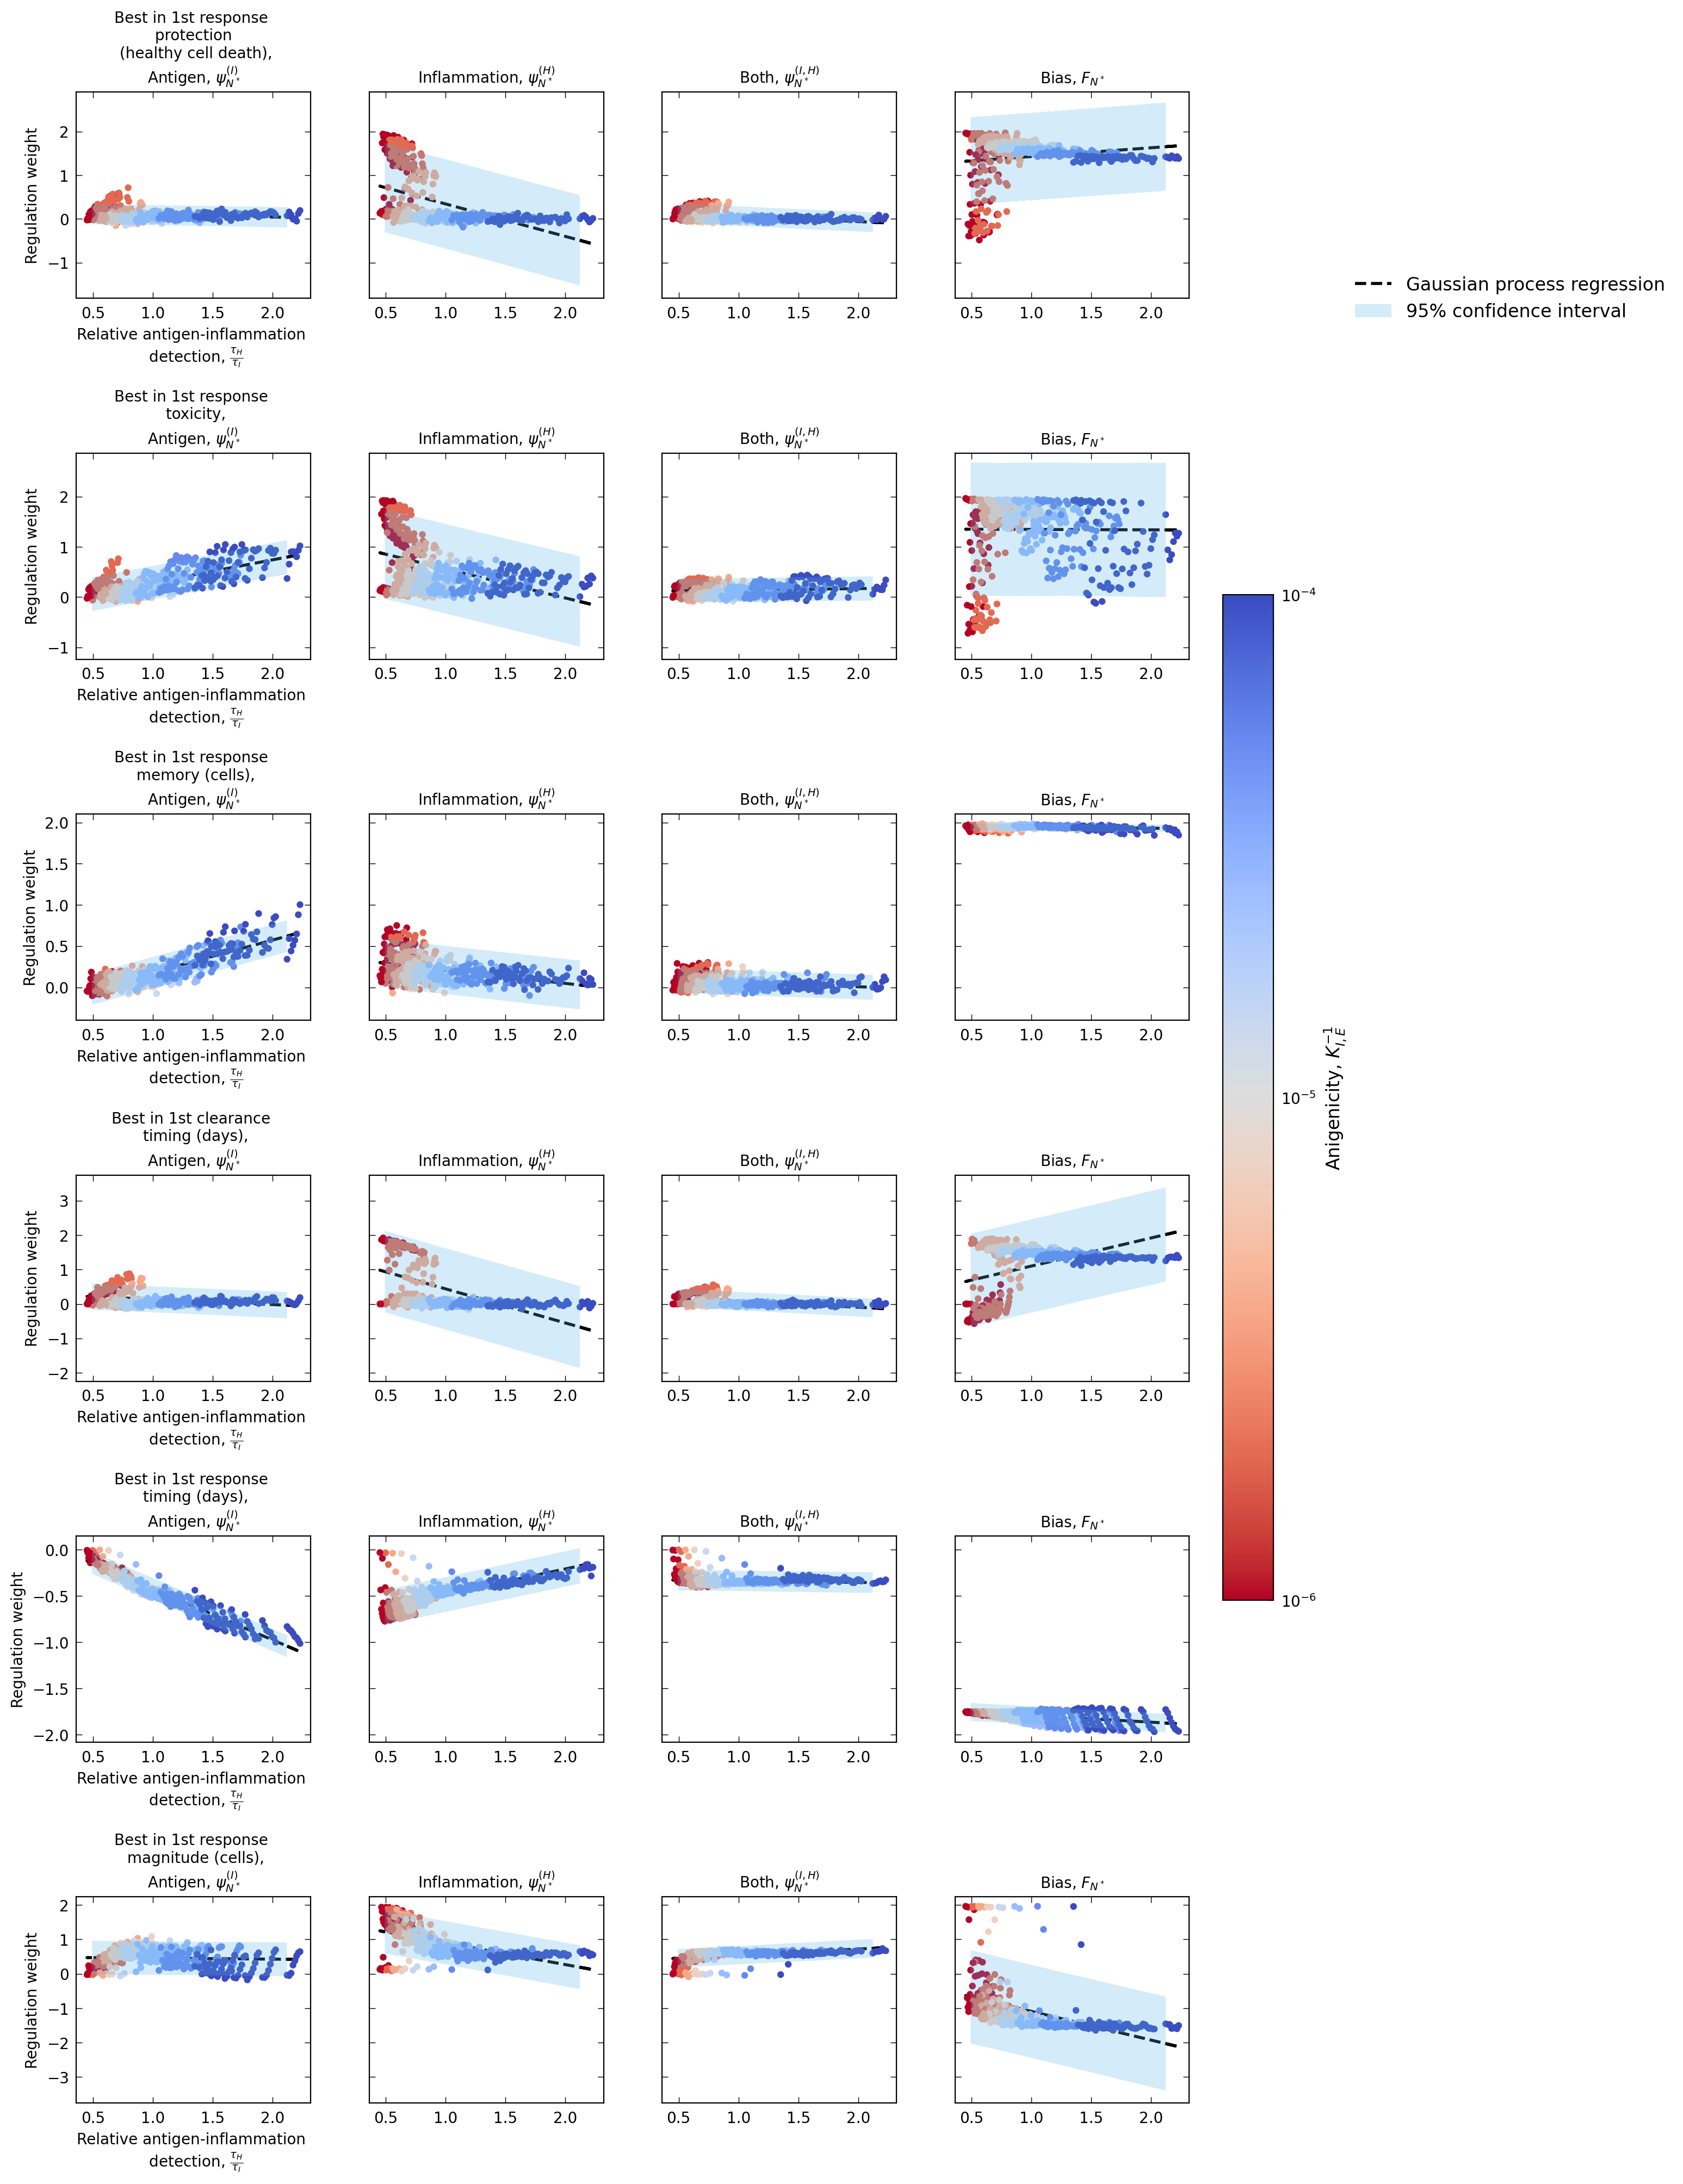

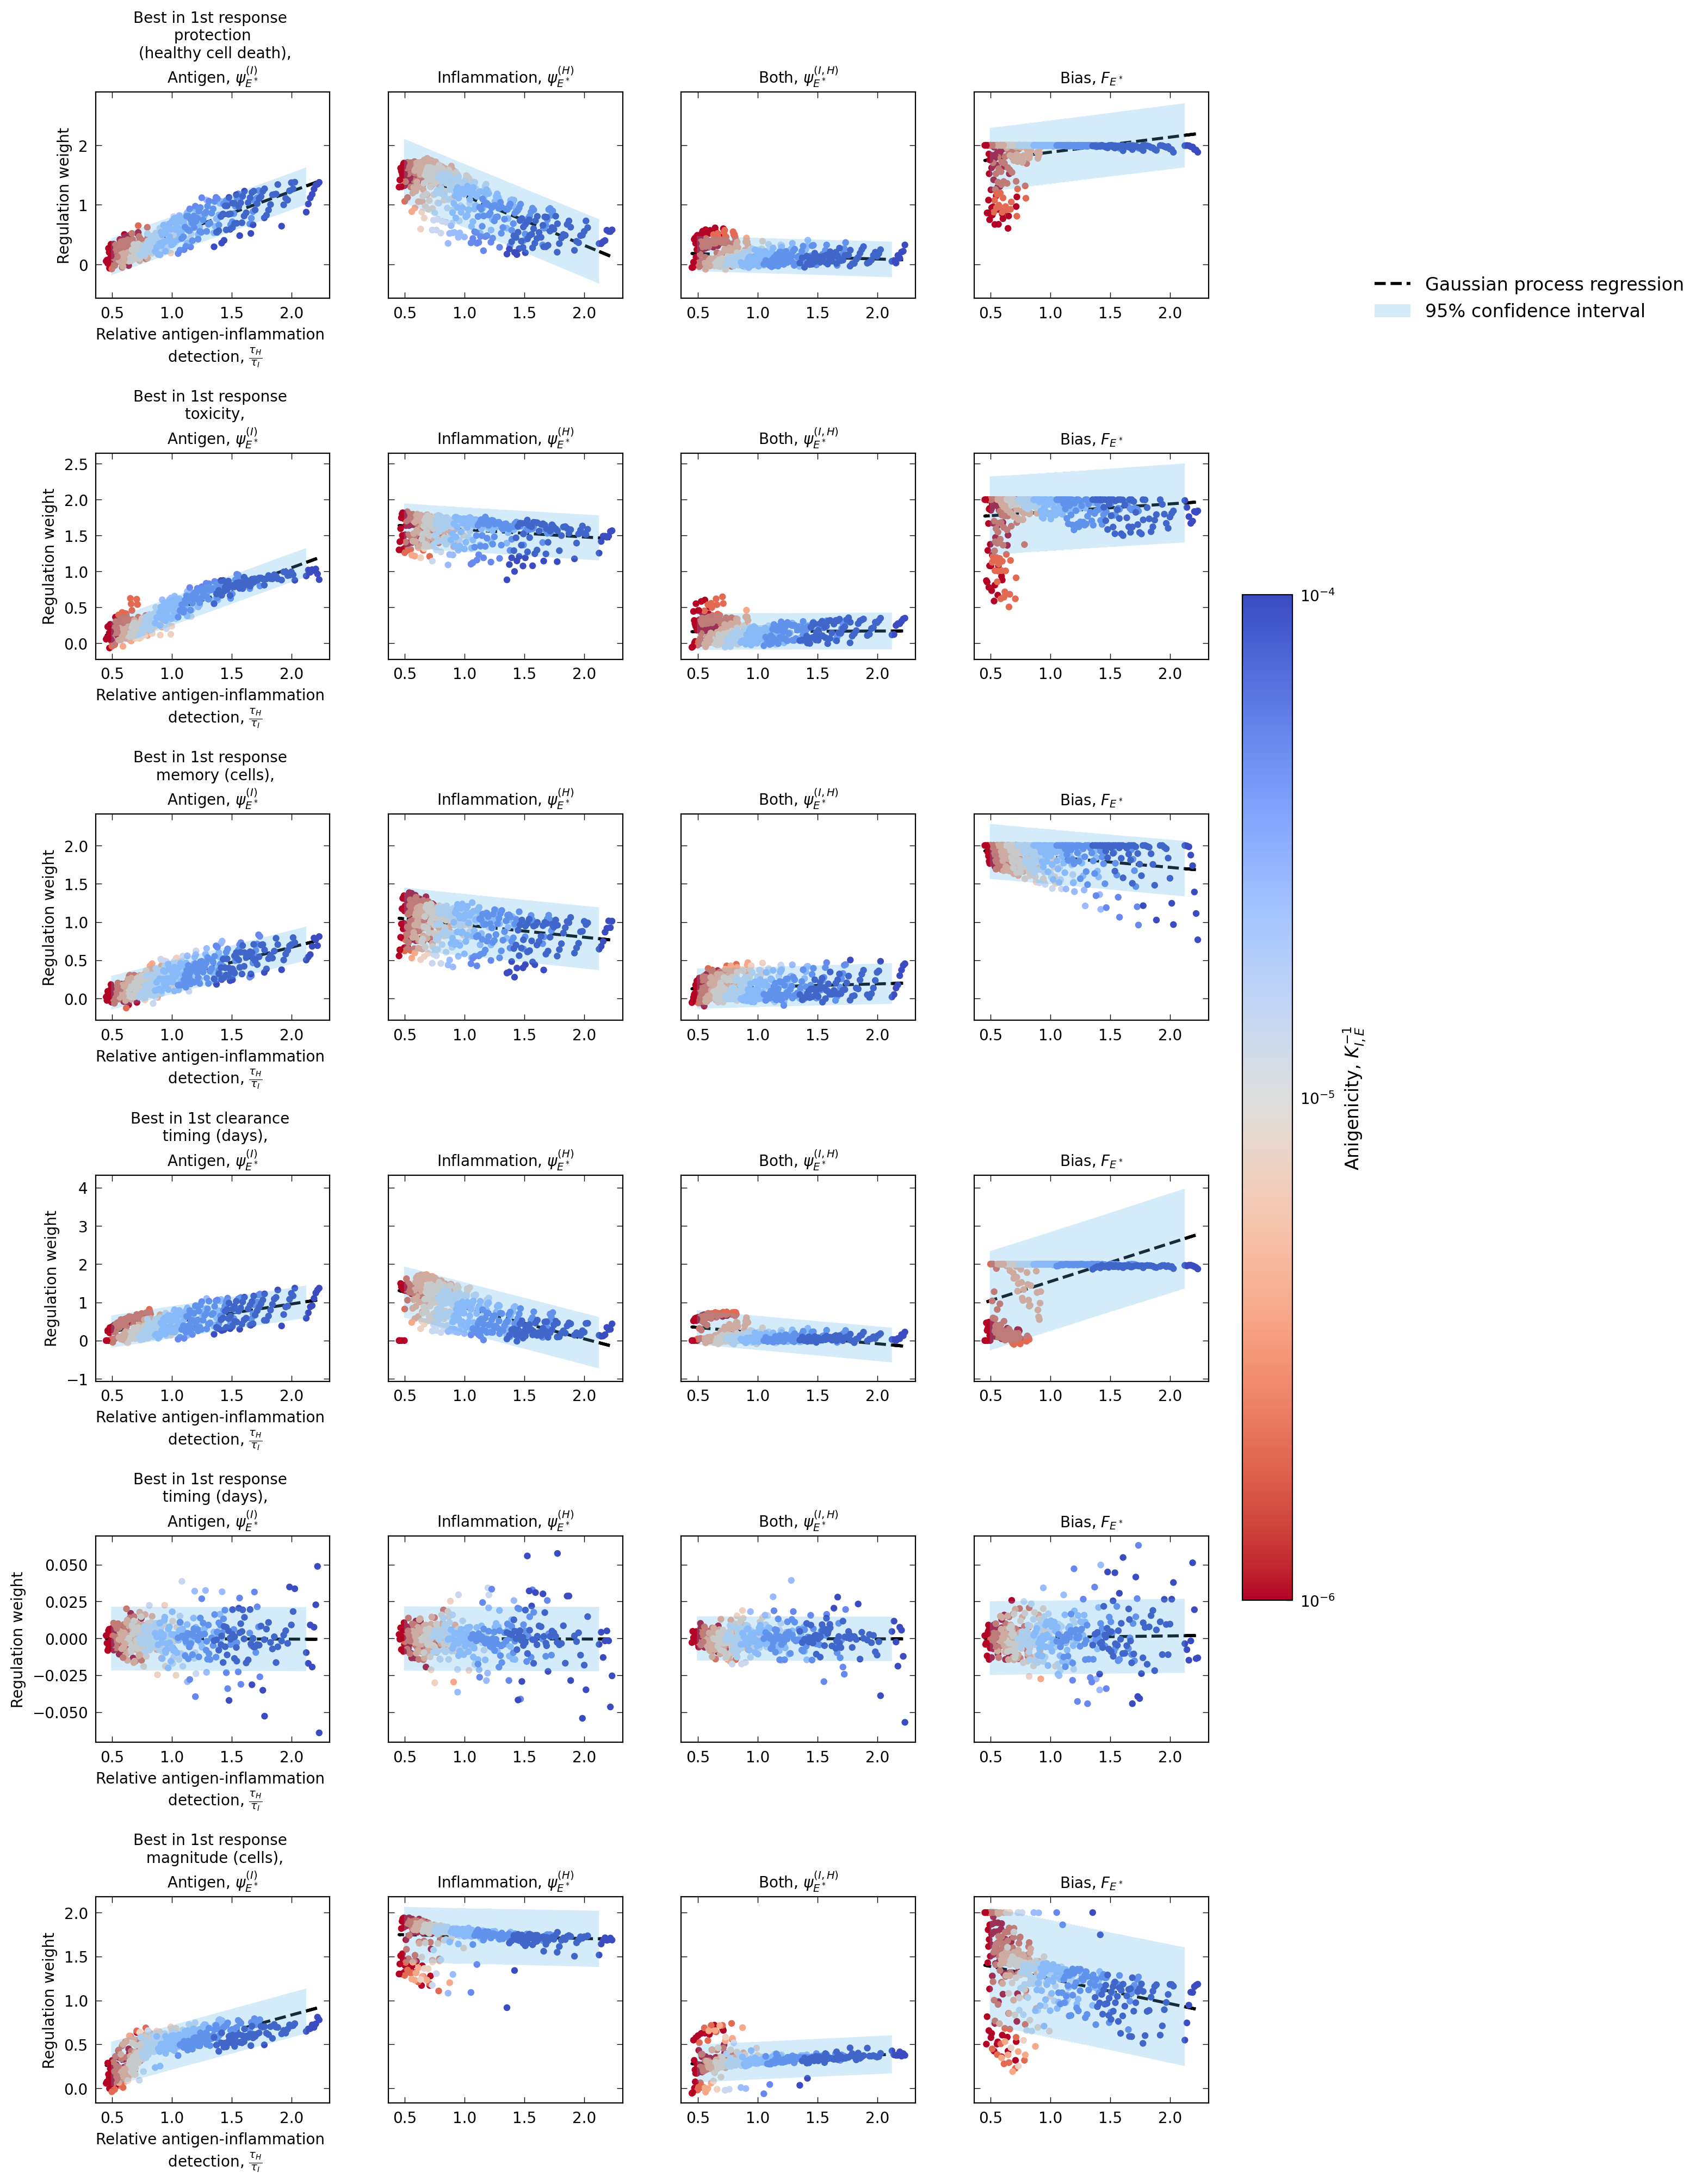

In [49]:
# Regulation of highest ranking networks
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='row', sharey='row')

    psi_IH = np.zeros(num_modules)
    bias = np.zeros(num_modules)
    
    for i, category in enumerate(perf_labels):
        vir_data_mean = df_perf_overall.loc[(df_perf_overall['perf_index'] == i)].copy() #*(np.max(np.abs(df_perf_overall[reg_and] - psi_IH), axis =1) == 0)*(np.max(np.abs(df_perf_overall[reg_bias] - bias), axis =1) == 0), reg + vir_vars + [x_varname, 'p_potential_harm', 'perf_index']]

        for j, p in enumerate(["Antigen", "Inflammation", "Both", "Bias"]):
            z_varname = reg_choice[j]
            z_label = p+", "+module_reg_labels[reg_choice_label][j]

            im = axs[i, j].scatter(vir_data_mean[x_varname], vir_data_mean[z_varname], 
                              marker =reg_markers[0], s = 20, c = 1/vir_data_mean['K_IE'], cmap='coolwarm_r', edgecolors = 'None', norm=mpl.colors.LogNorm())

            axs[i, j].set_title((r'Best in '+perf_labels[i]+',\n' if j == 0 else '') + z_label, fontsize = 10.0)

            # Plot kernel fit
            kernel = DotProduct() + WhiteKernel()
            X, Y = vir_data_mean[x_varname].values.reshape(-1, 1), vir_data_mean[z_varname].values.reshape(-1, 1)
            gpr = GaussianProcessRegressor(kernel=kernel,
                    random_state=0).fit(X, Y)
            gpr.score(X, Y)
            y_pred, std_pred = gpr.predict(X, return_std=True)
            axs[i, j].plot(X, y_pred,'k--', label = 'Gaussian process regression', linewidth = 2, zorder = 0)
            axs[i, j].fill_between(X.ravel(), y_pred - 1.96 * std_pred, y_pred + 1.96 * std_pred, alpha=0.25,label=r"95% confidence interval")
            axs[i, j].minorticks_off()
    
    axs[0,-1].legend(loc='center right', bbox_to_anchor=(3.1, 0.0), fontsize = 12)
    fig_c.subplots_adjust(wspace=.25, hspace=0.75)
    cb = fig_c.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.025)
    cb.set_label(r'Anigenicity, $K_{I,E}^{-1}$', fontsize = 12)
    
    for k, ax in enumerate(axs.flat):
        if k % (2*num_modules) == 0:
            ax.set_xlabel(key_var_label, fontsize = 10)
            ax.set_ylabel("Regulation weight", fontsize = 10)

    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-regulation_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")
    del vir_data_mean

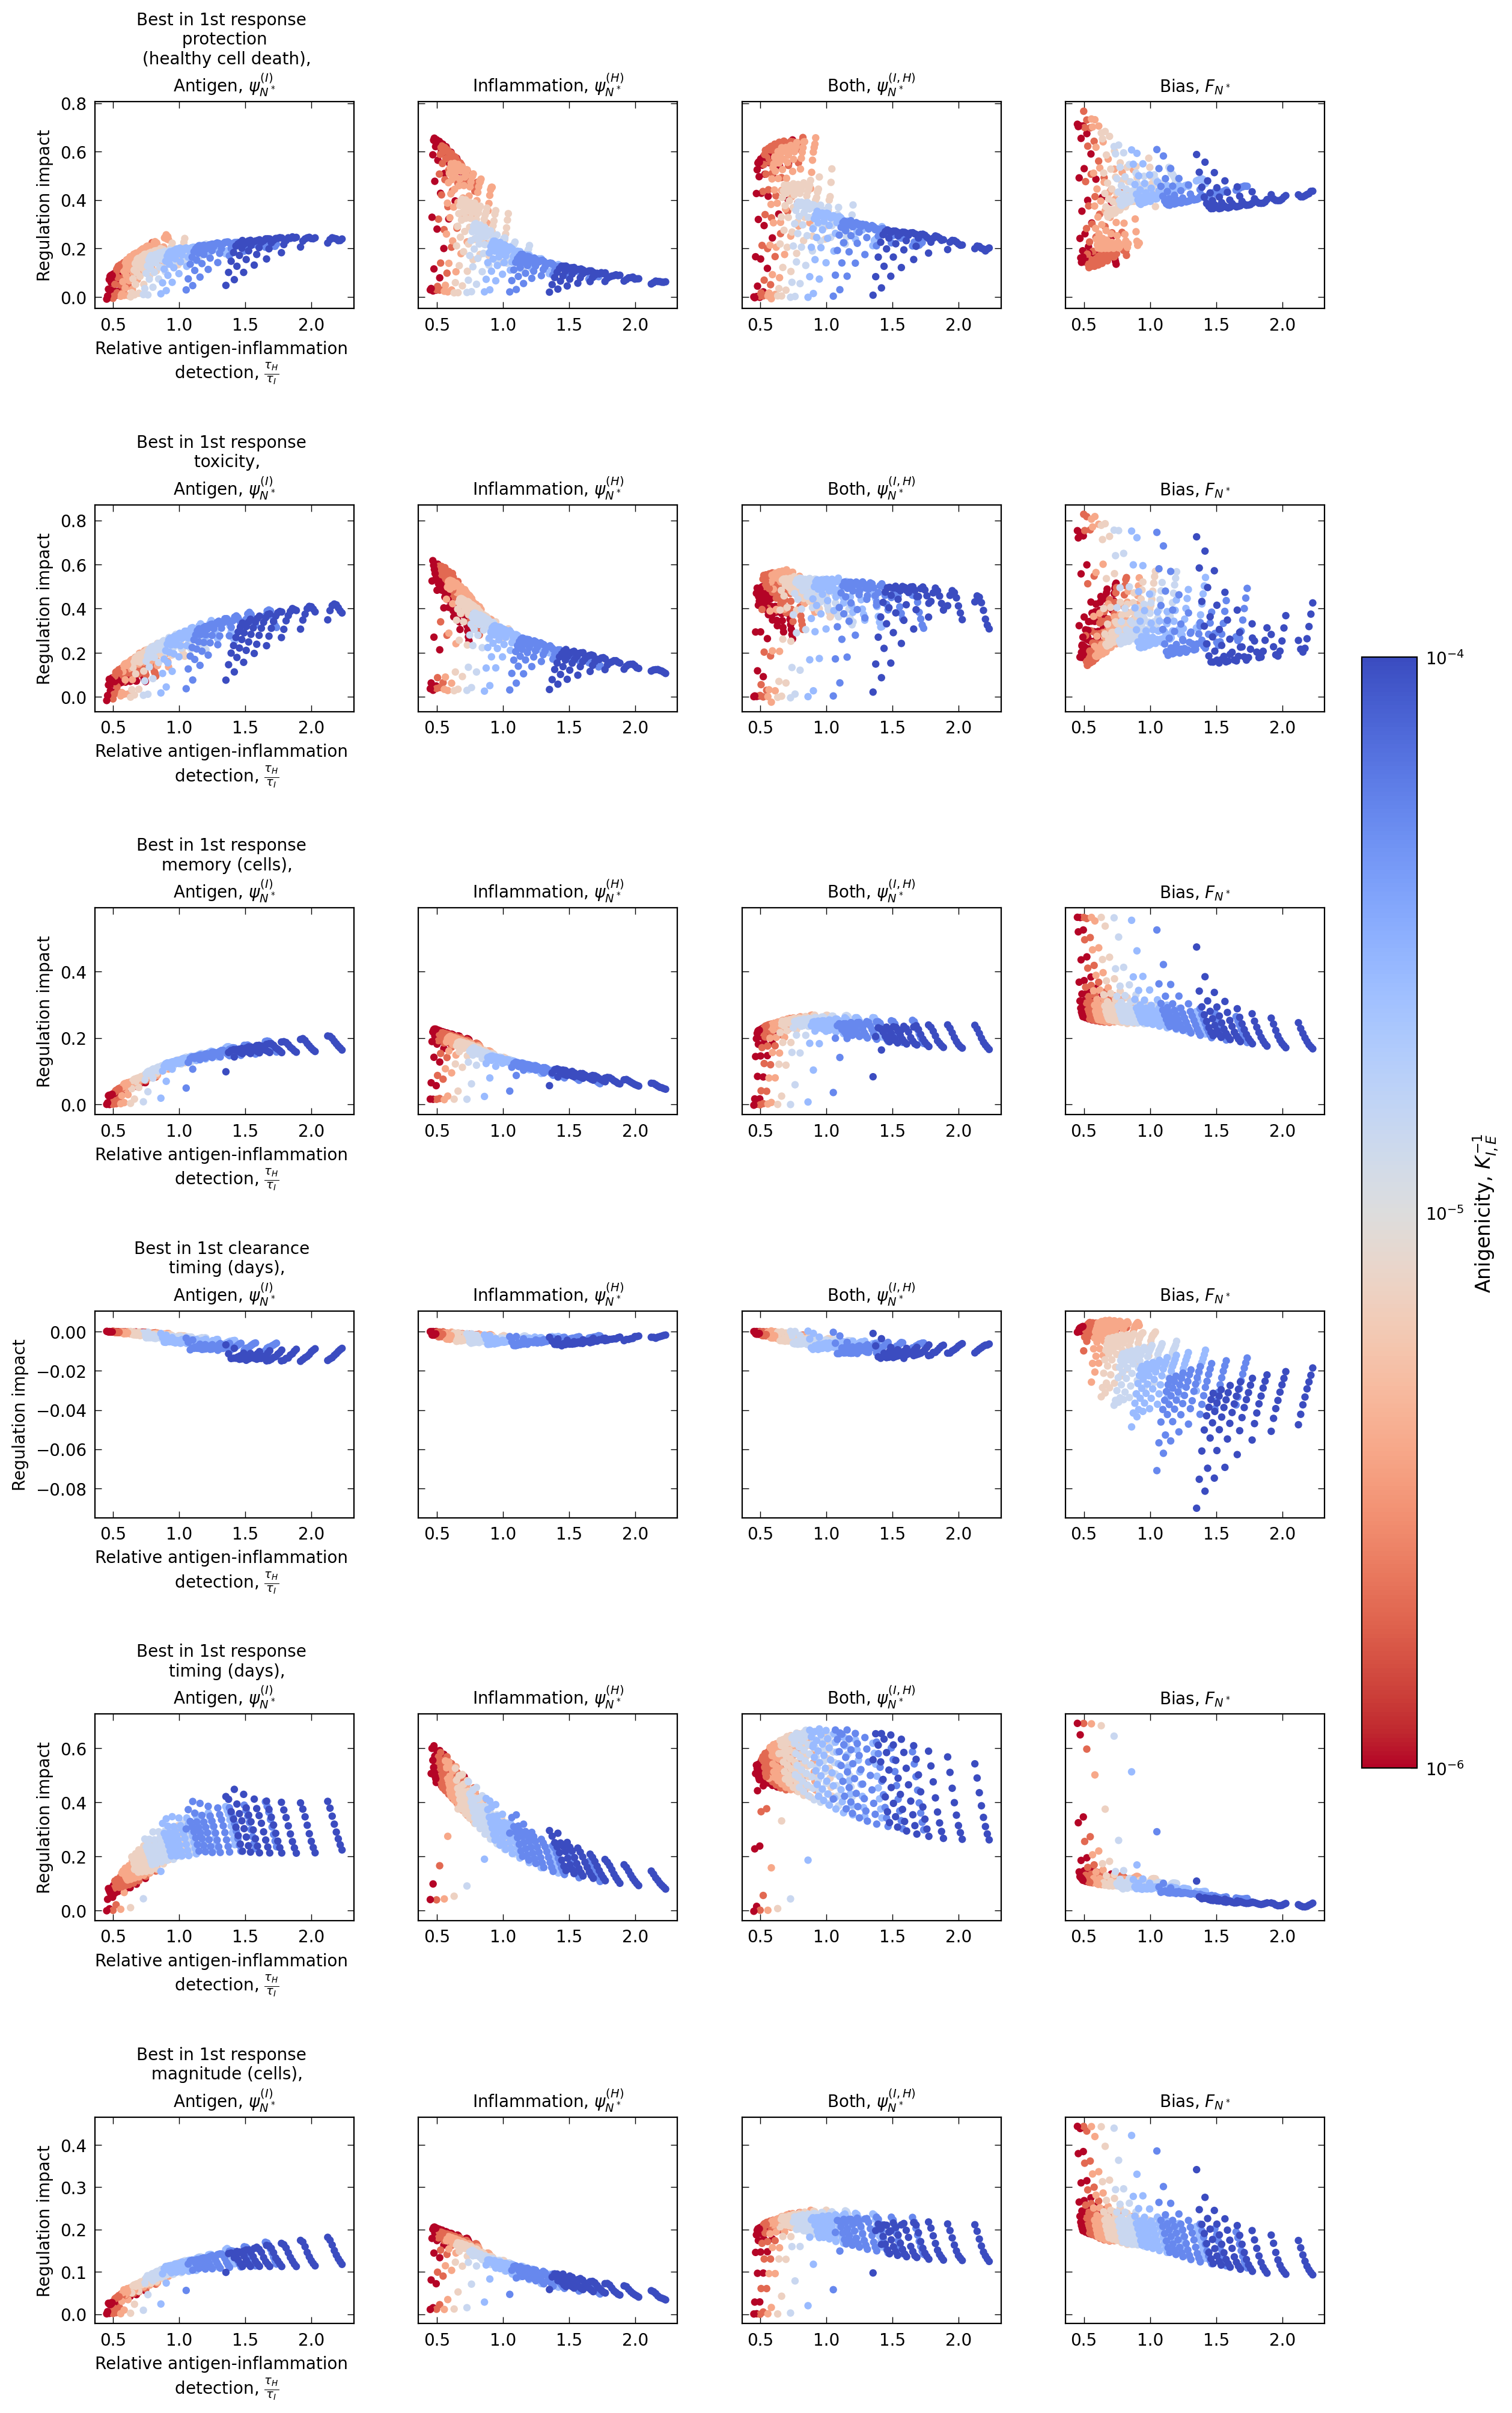

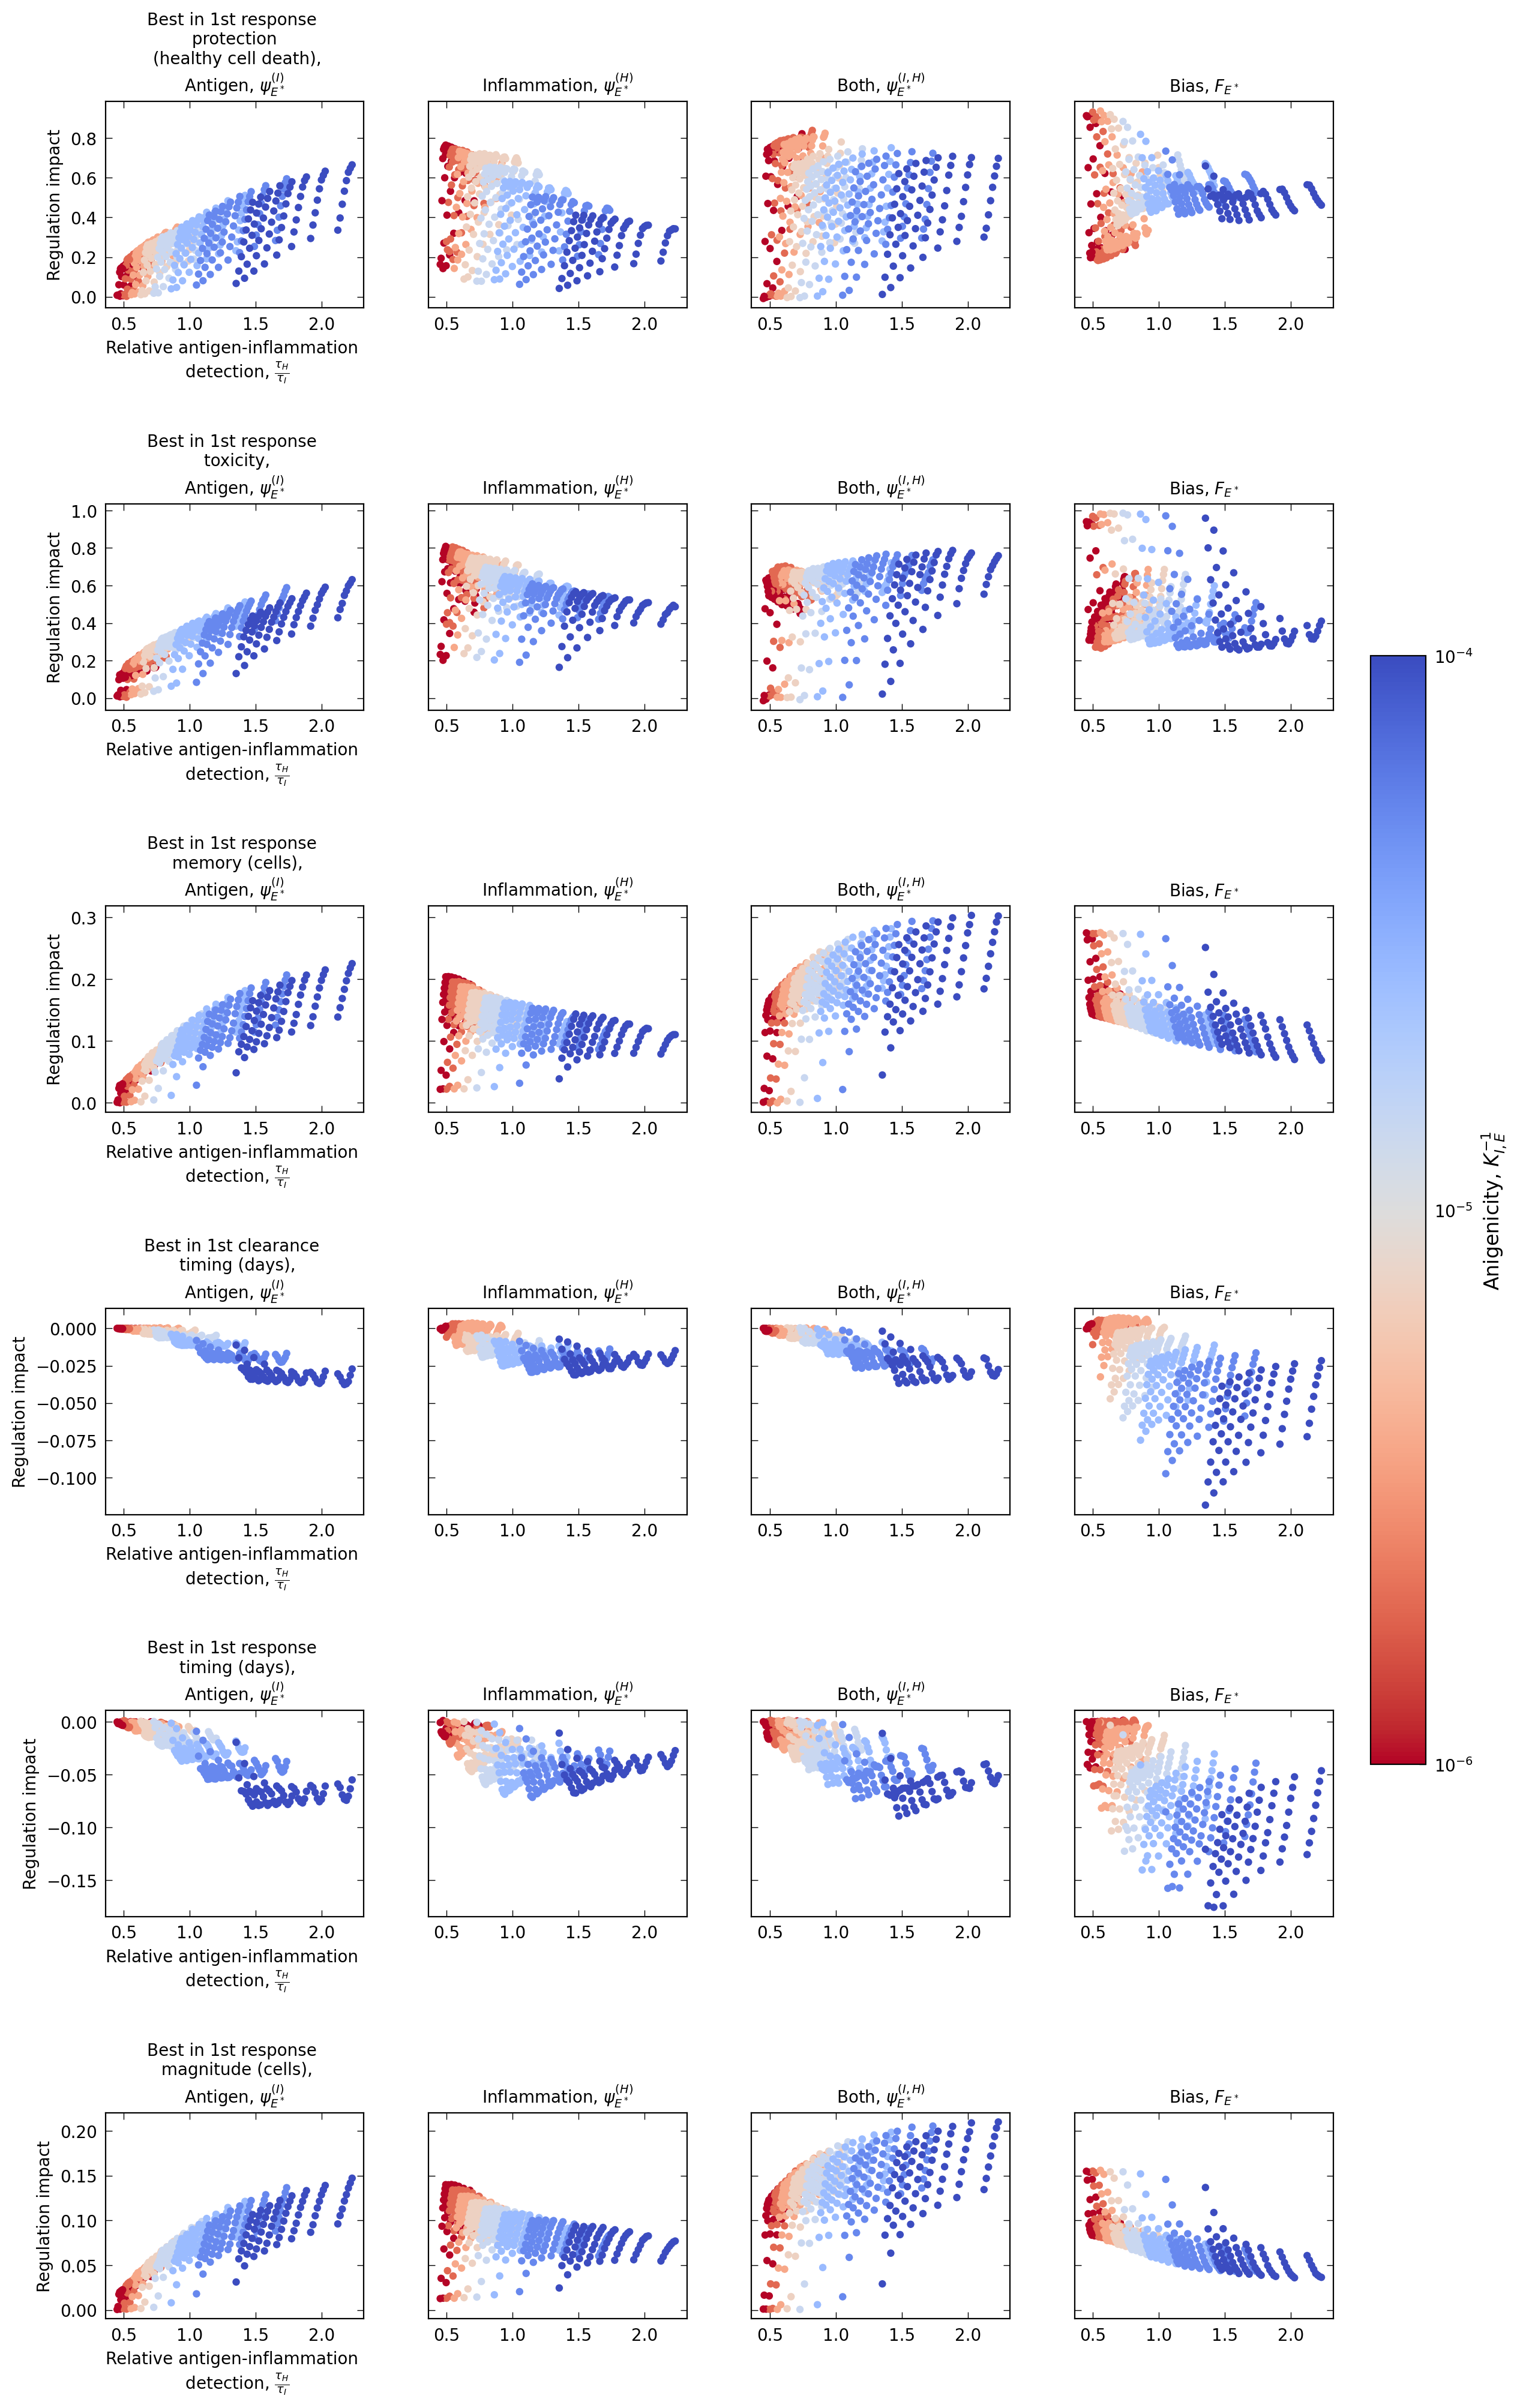

In [50]:
# Regulation of highest ranking networks
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='row', sharey='row')
    
    for i, category in enumerate(perf_labels):
        vir_data_mean = impact_data.loc[(impact_data['perf_index'] == i)]
        #vir_data_mean.sort_values(by=[key_var], inplace=True)
        for j, p in enumerate(["Antigen", "Inflammation", "Both", "Bias"]):
            y_varname = reg_choice[j]
            y_label = p+", "+module_reg_labels[reg_choice_label][j]

            im = axs[i, j].scatter(vir_data_mean[x_varname], vir_data_mean[y_varname], 
                              marker =reg_markers[0], s = 20, c = 1/vir_data_mean['K_IE'], cmap='coolwarm_r', edgecolors = 'None', norm=mpl.colors.LogNorm())

            axs[i, j].set_title((r'Best in '+perf_labels[i]+',\n' if j == 0 else '') + y_label, fontsize = 10.0)
            axs[i, j].minorticks_off()
    
    fig_c.subplots_adjust(wspace=.25, hspace=0.95)
    cb = fig_c.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.025)
    cb.set_label(r'Anigenicity, $K_{I,E}^{-1}$', fontsize = 12)
    
    for k, ax in enumerate(axs.flat):
        if k % (2*num_modules) == 0:
            ax.set_xlabel(key_var_label, fontsize = 10)
            ax.set_ylabel("Regulation impact", fontsize = 10)

    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-regulation_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")
    del vir_data_mean

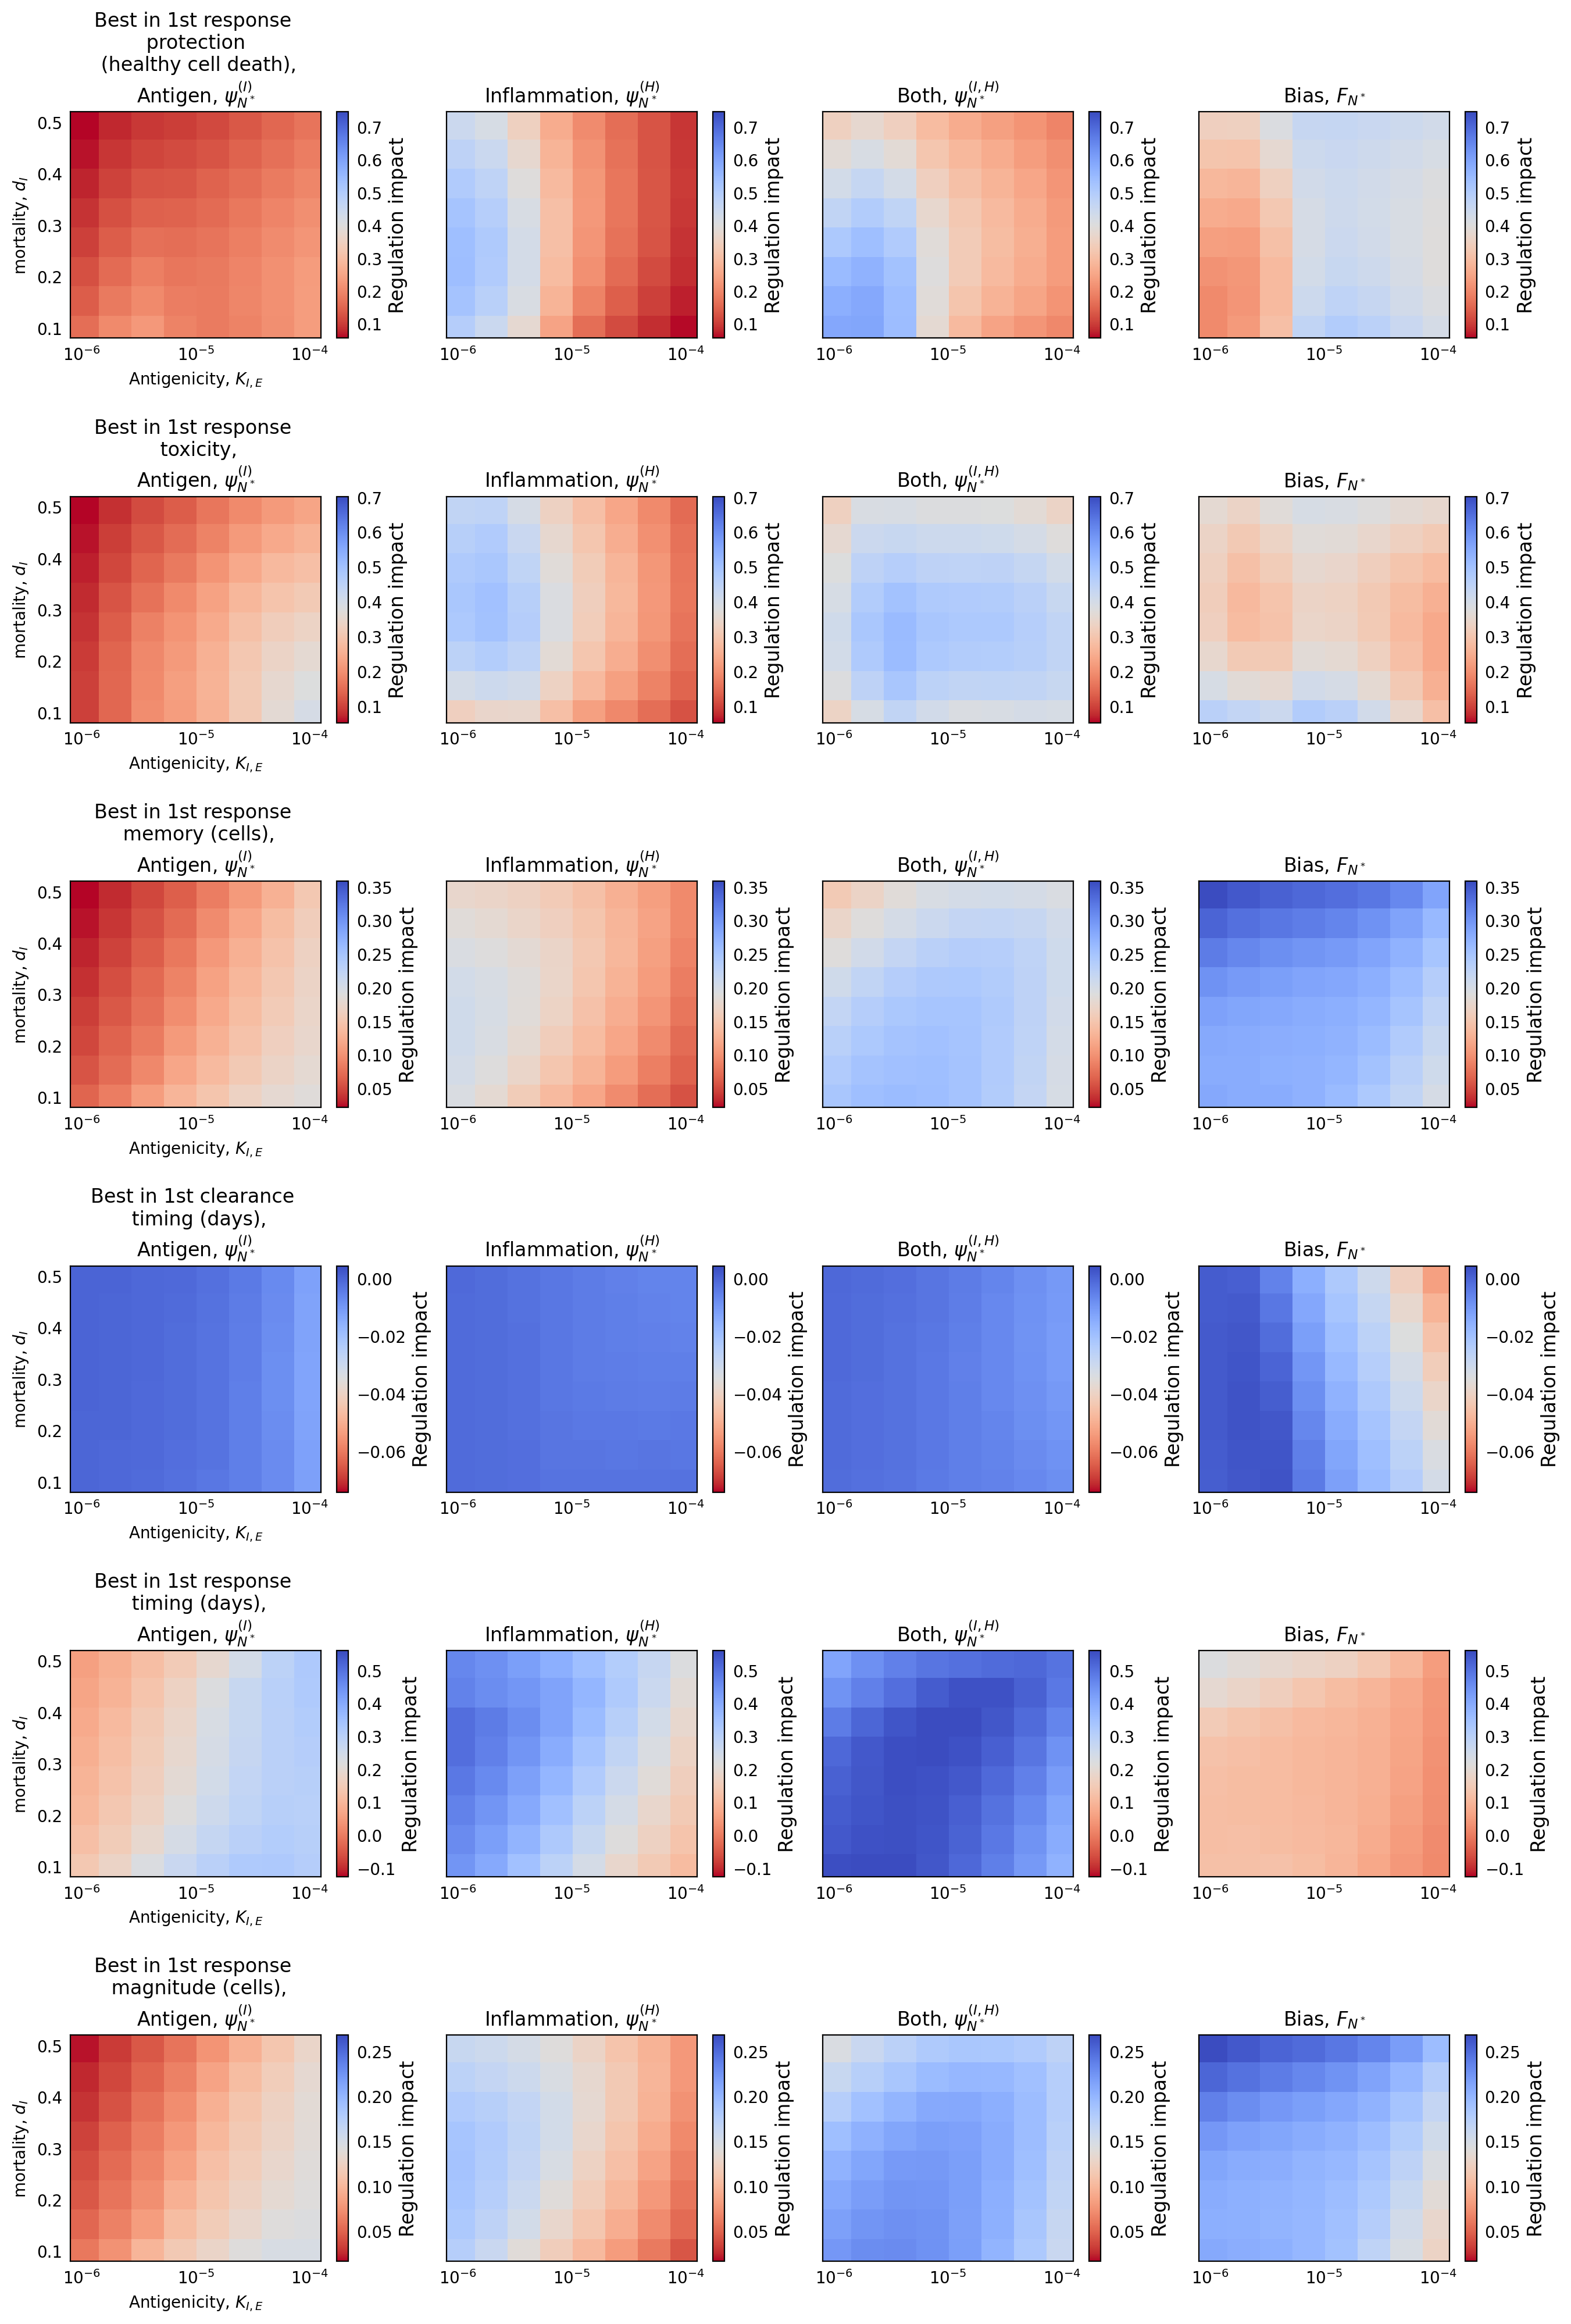

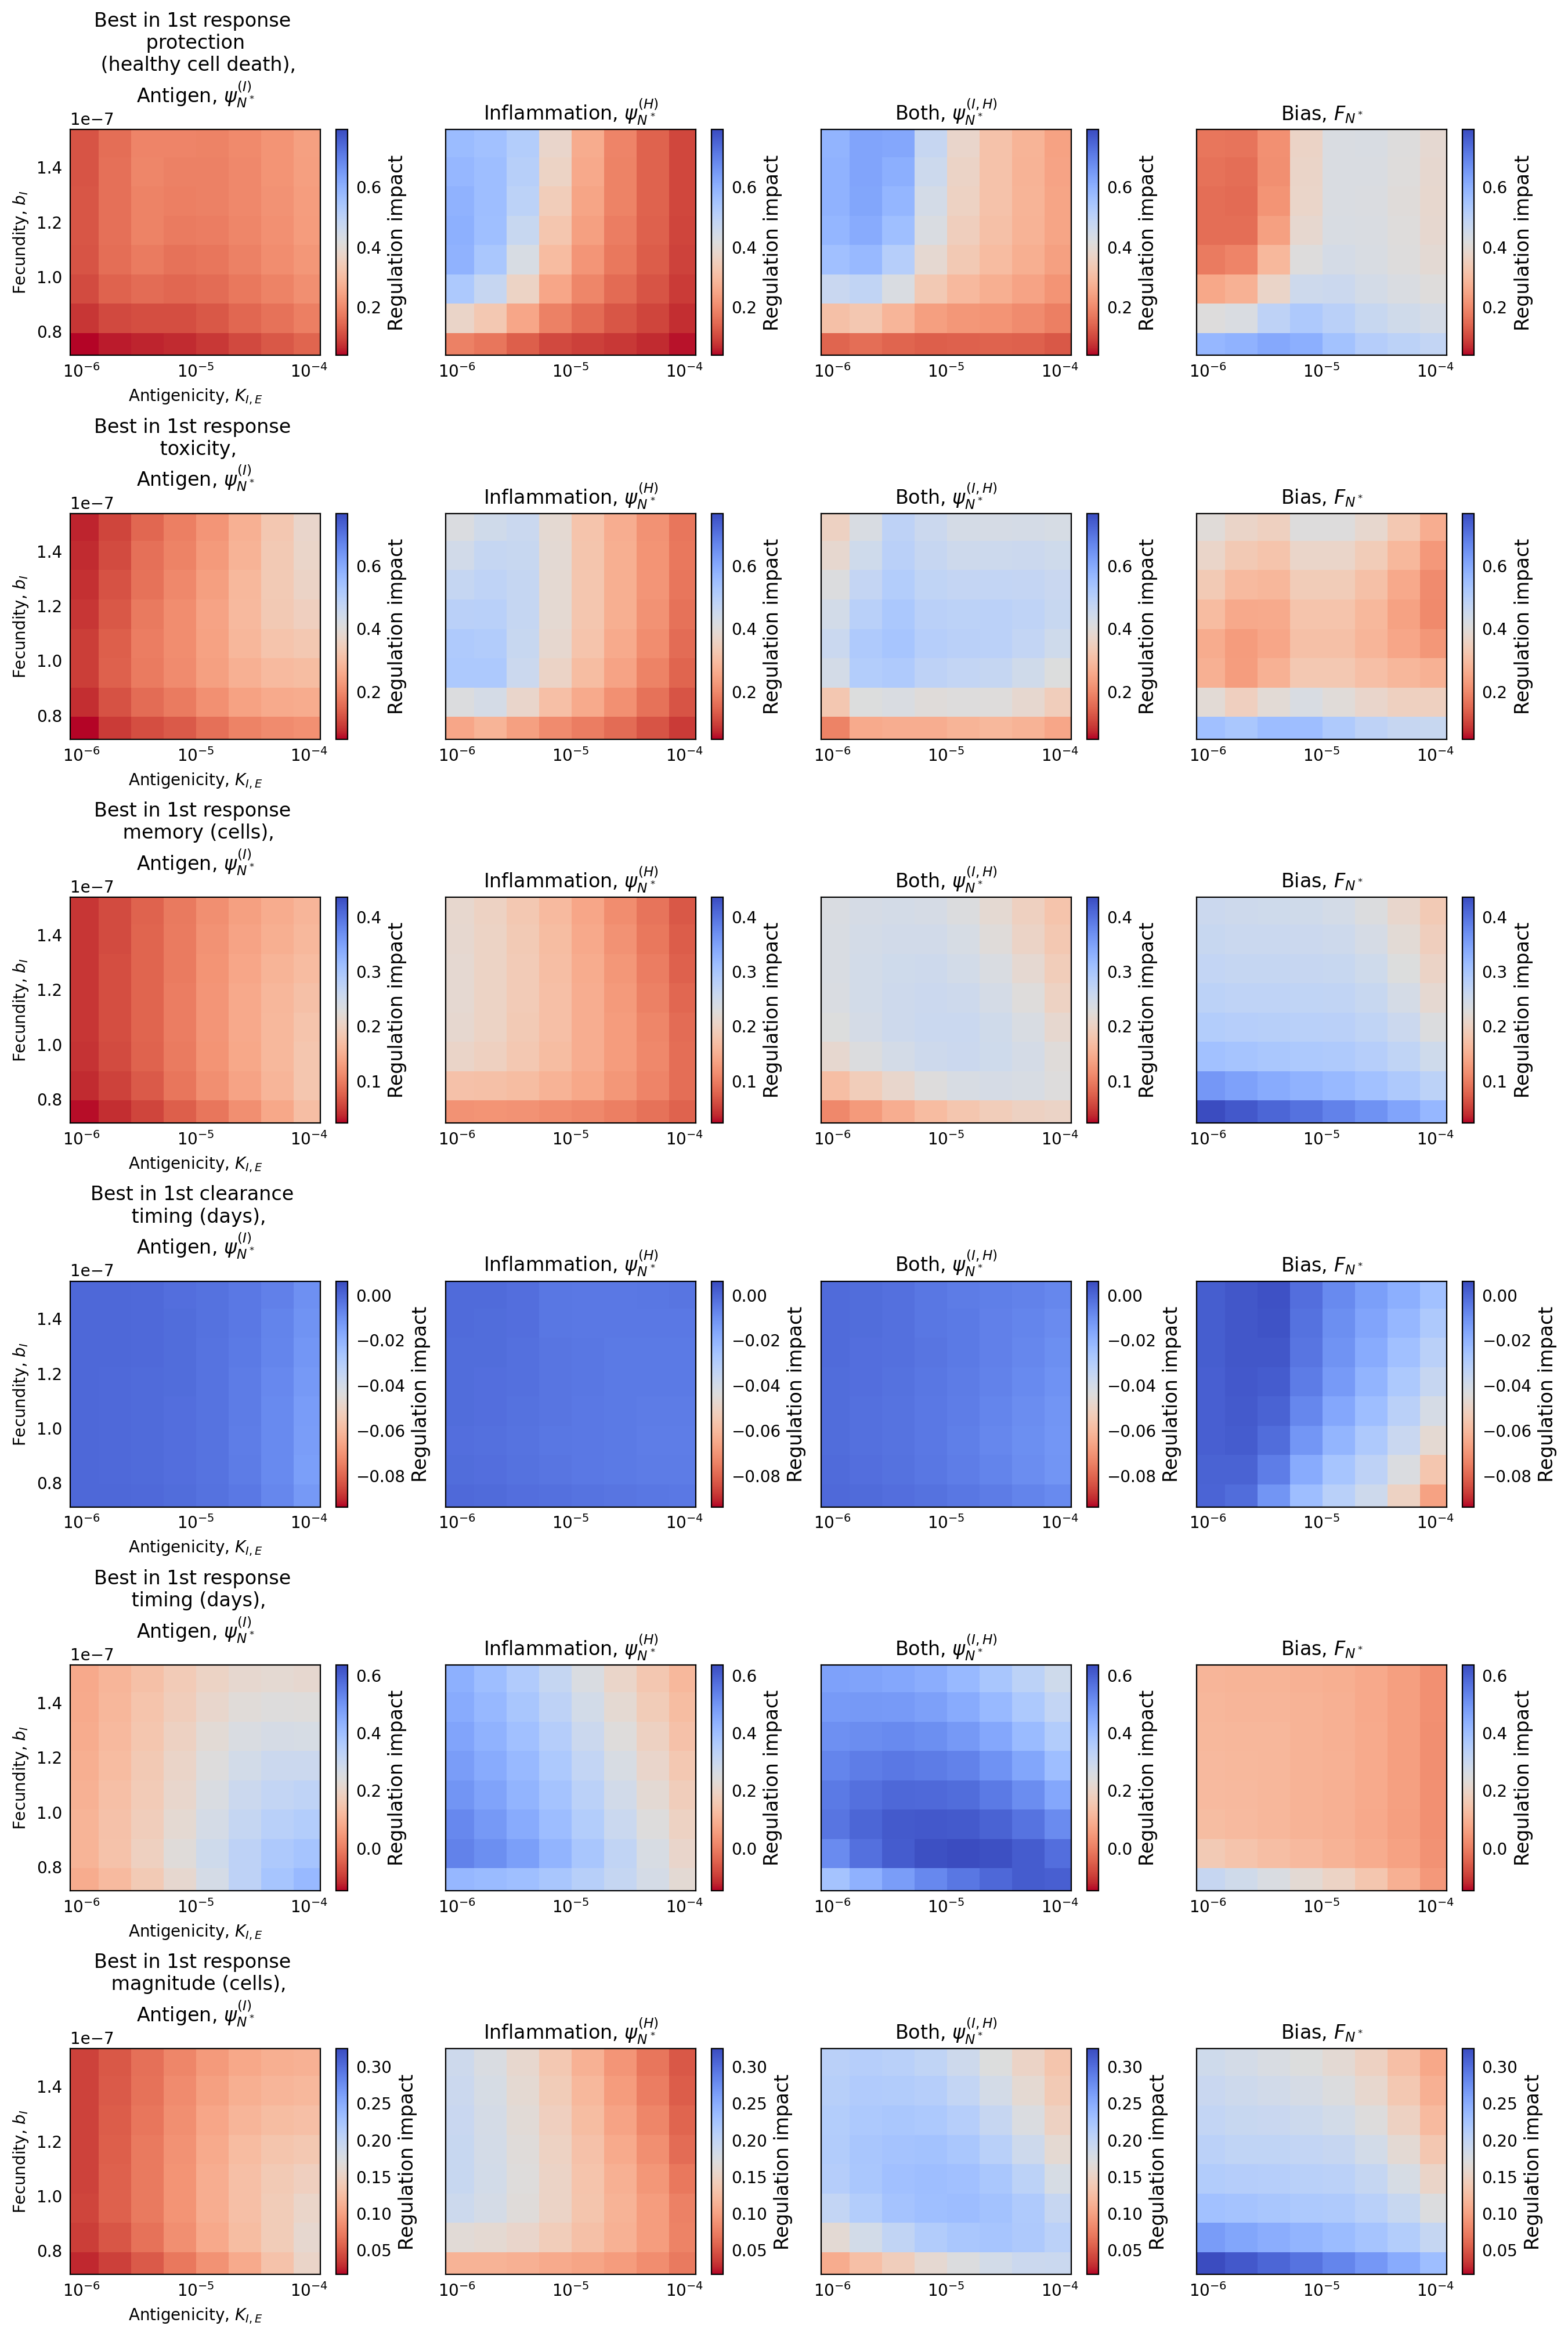

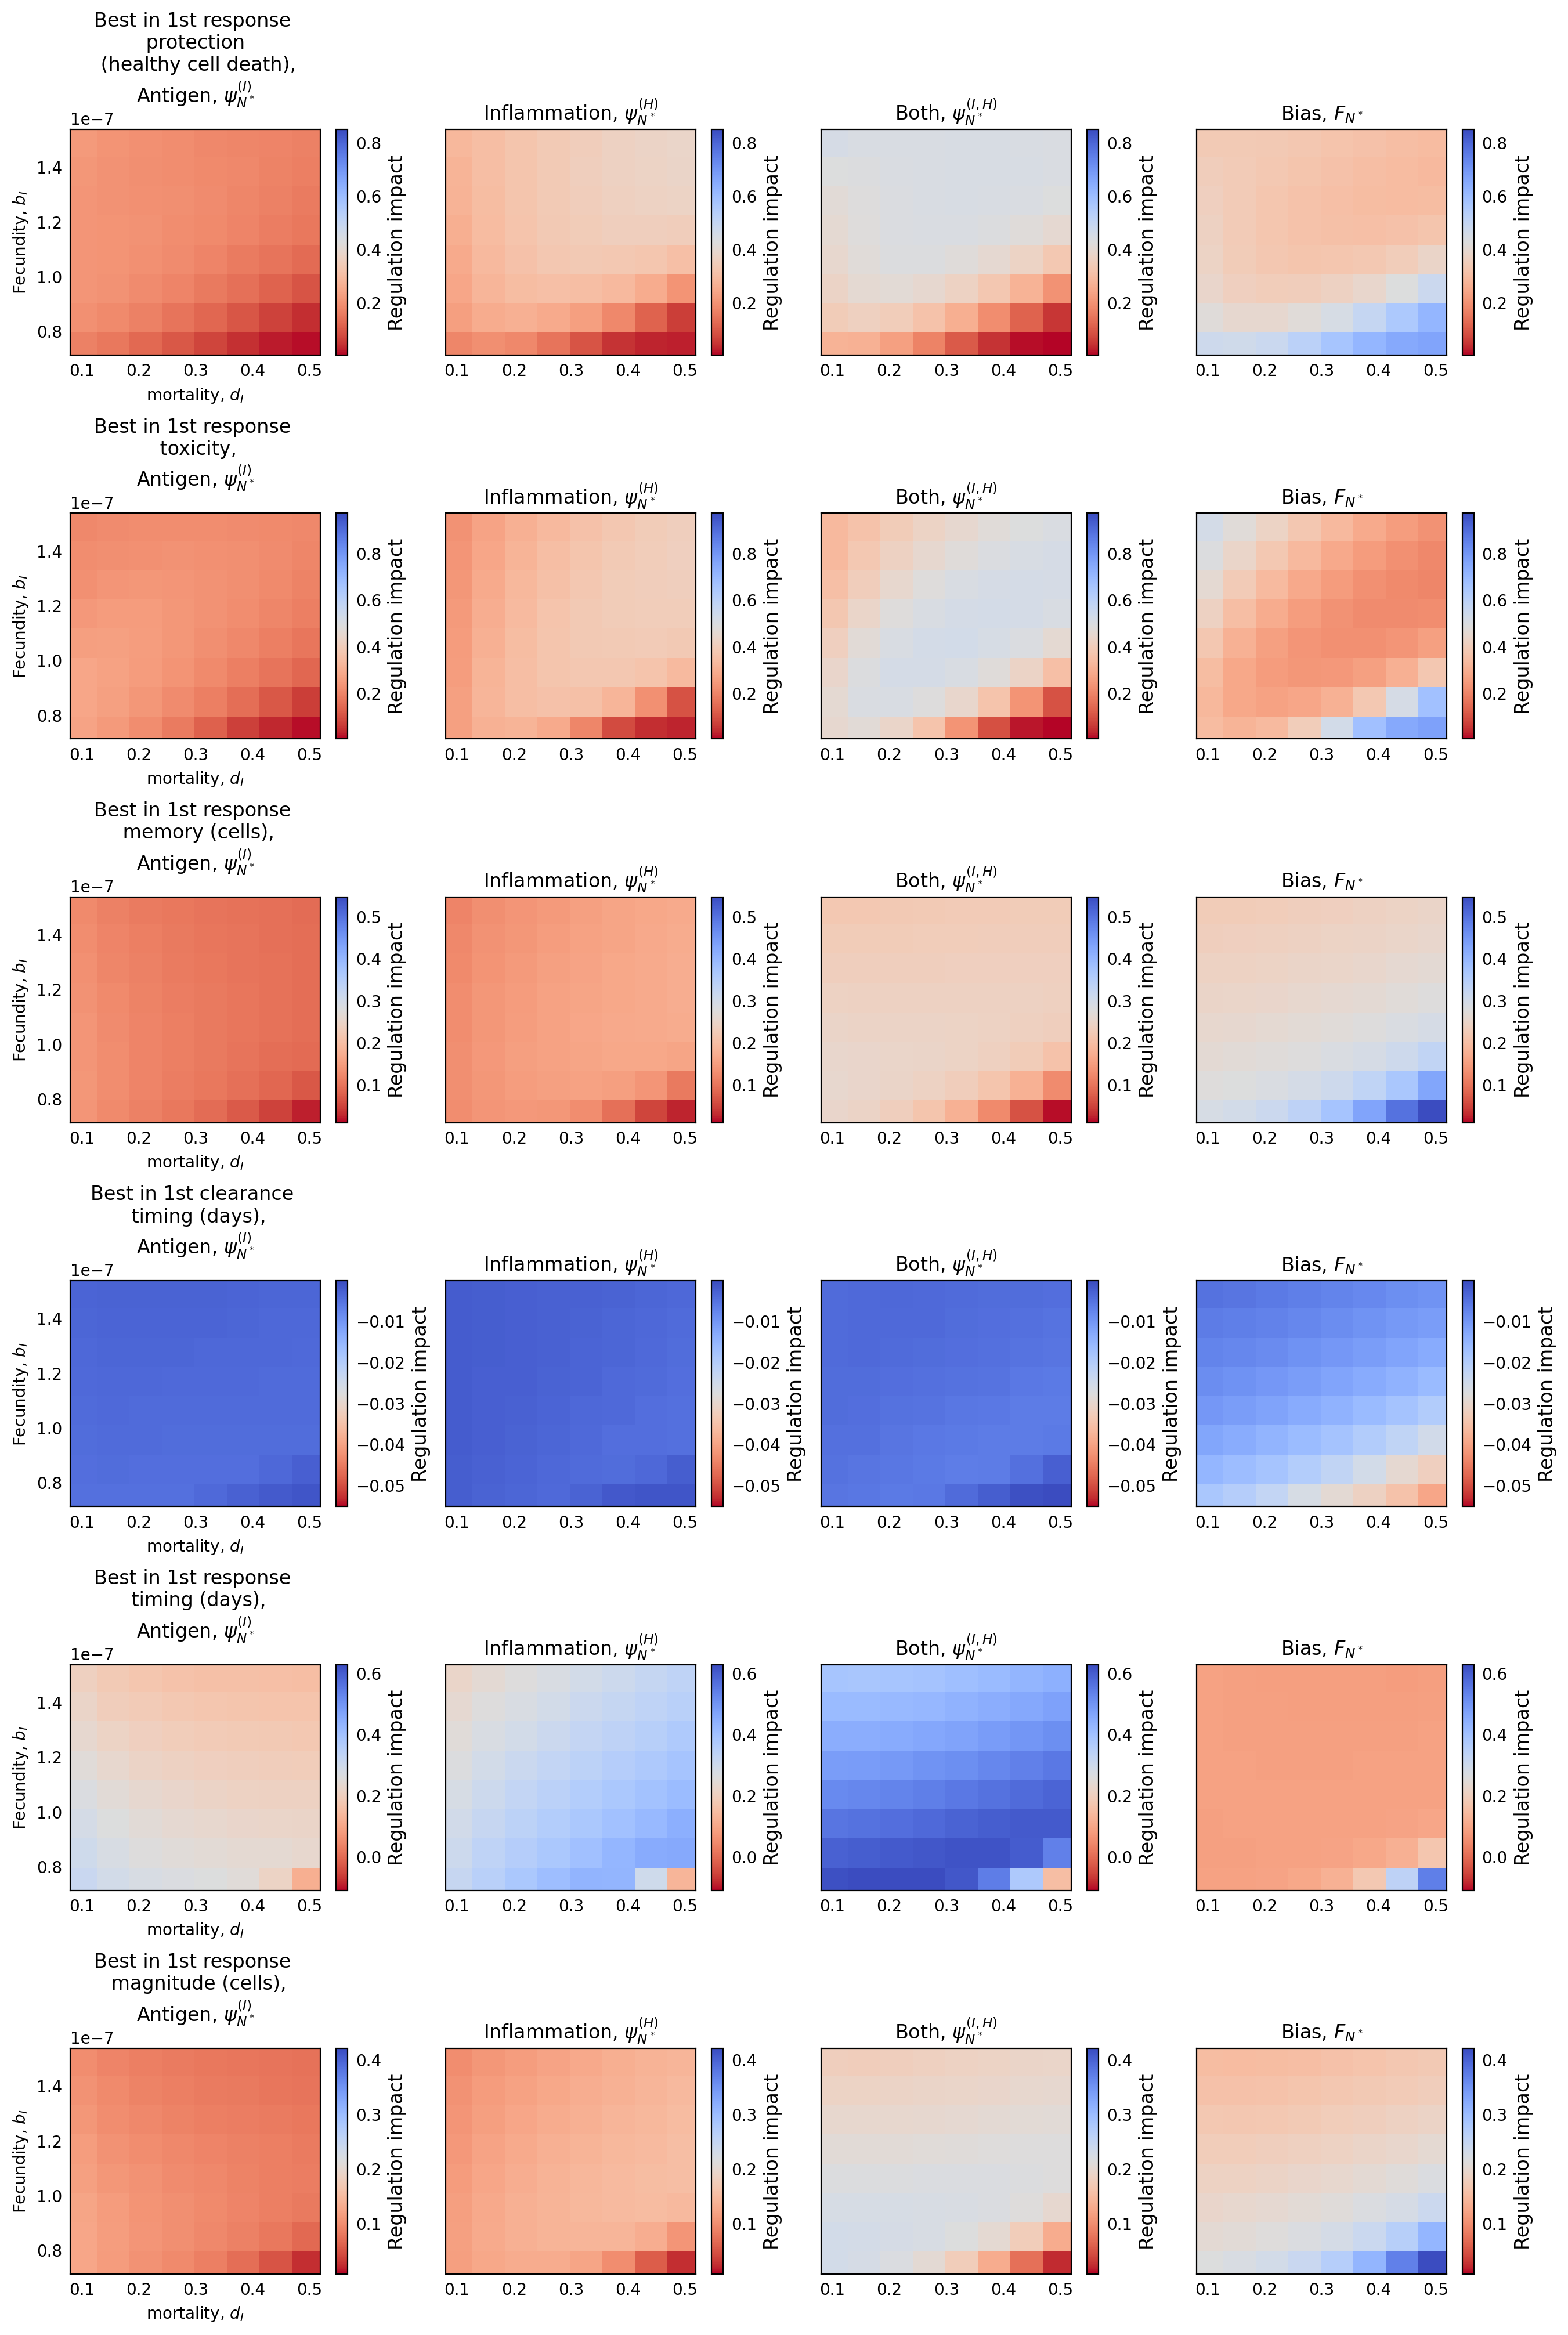

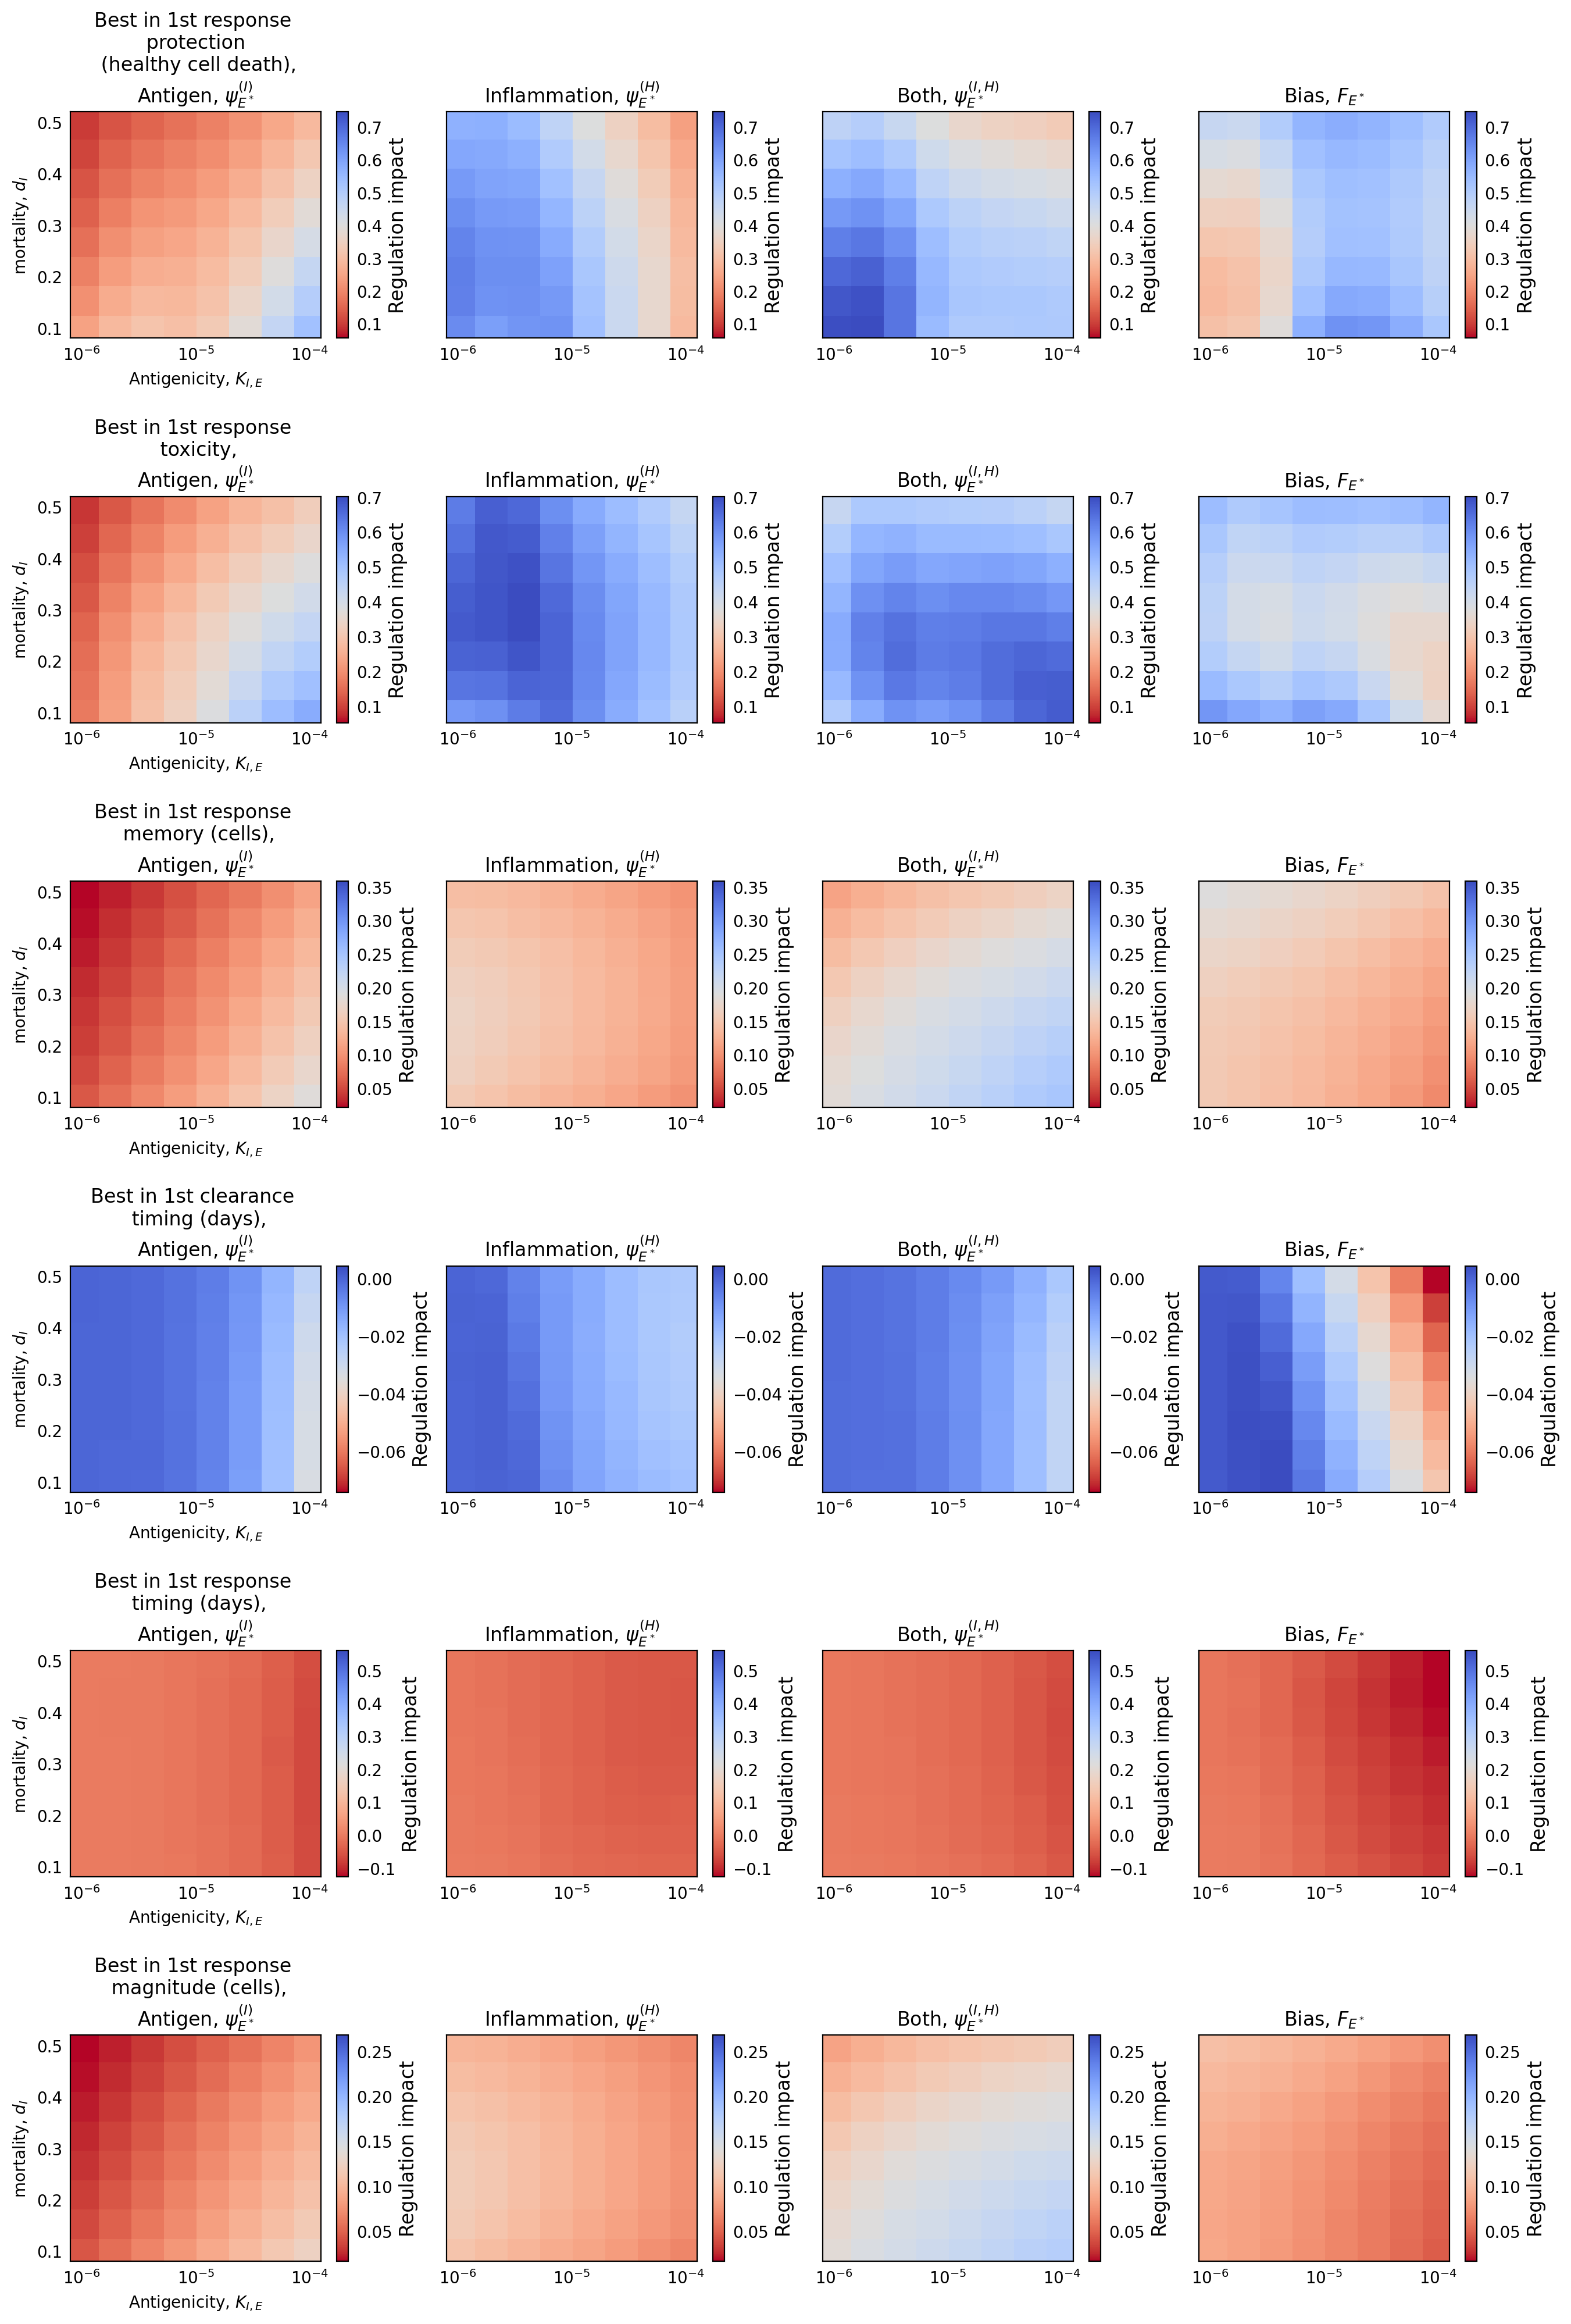

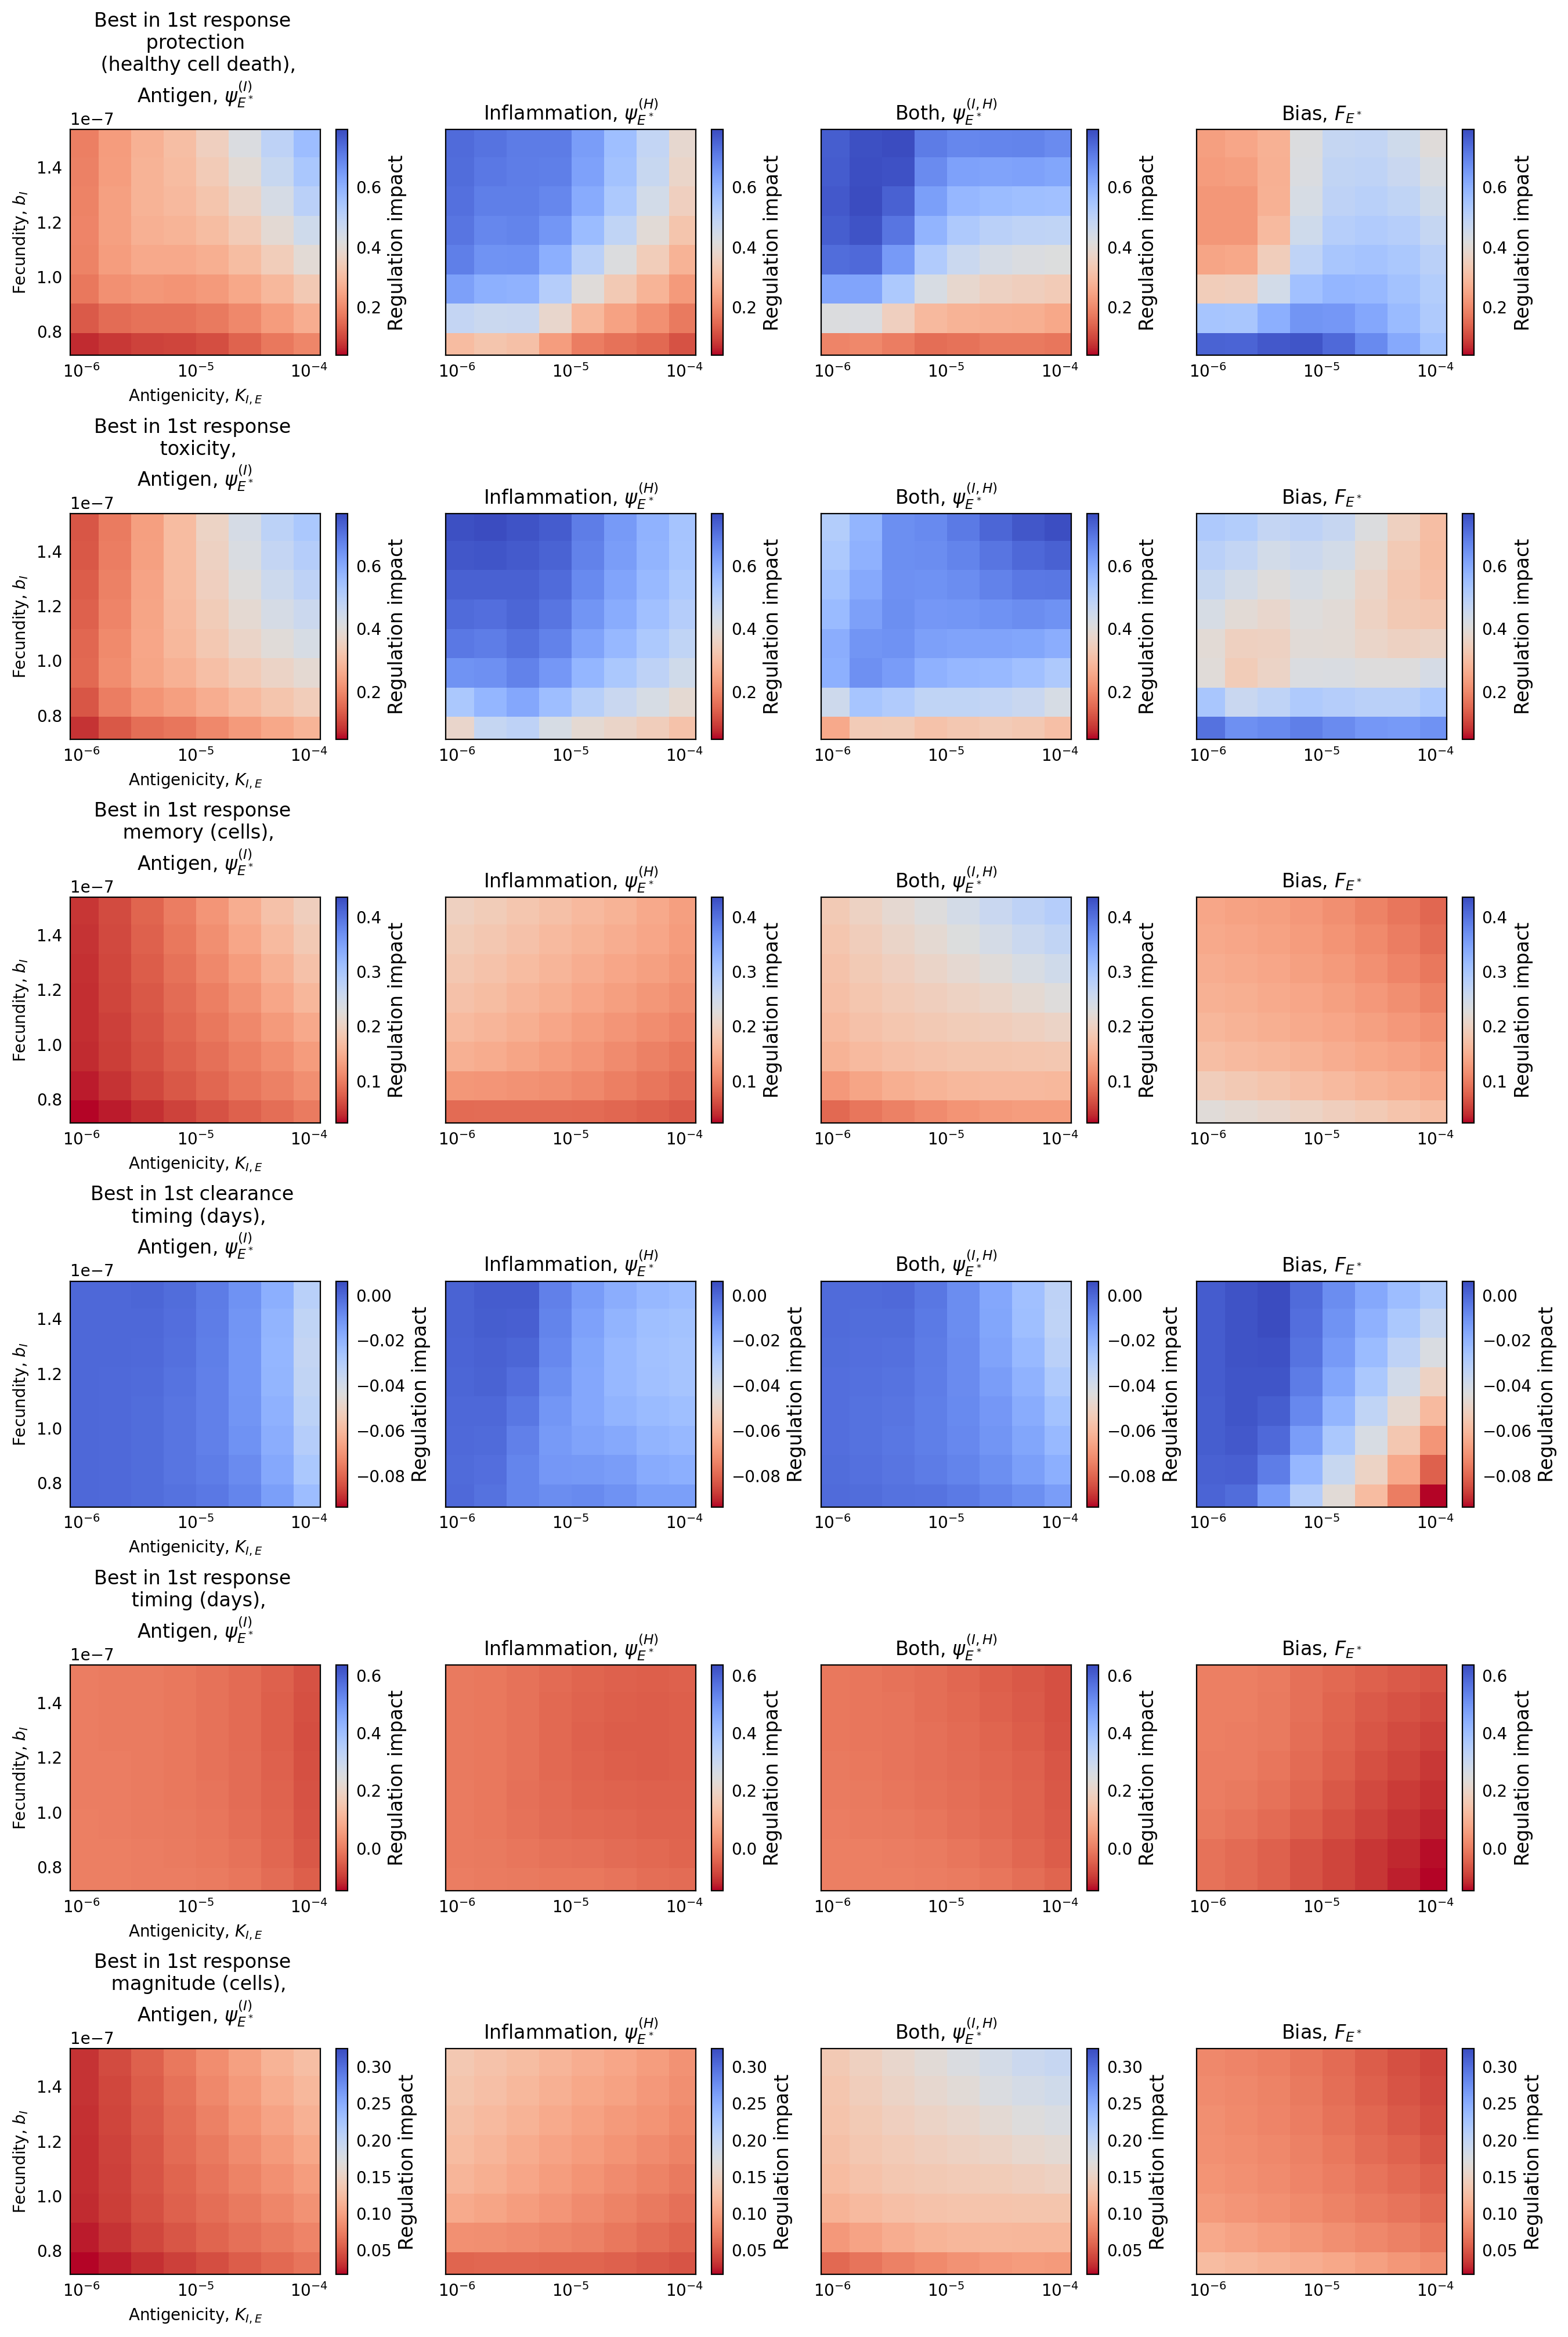

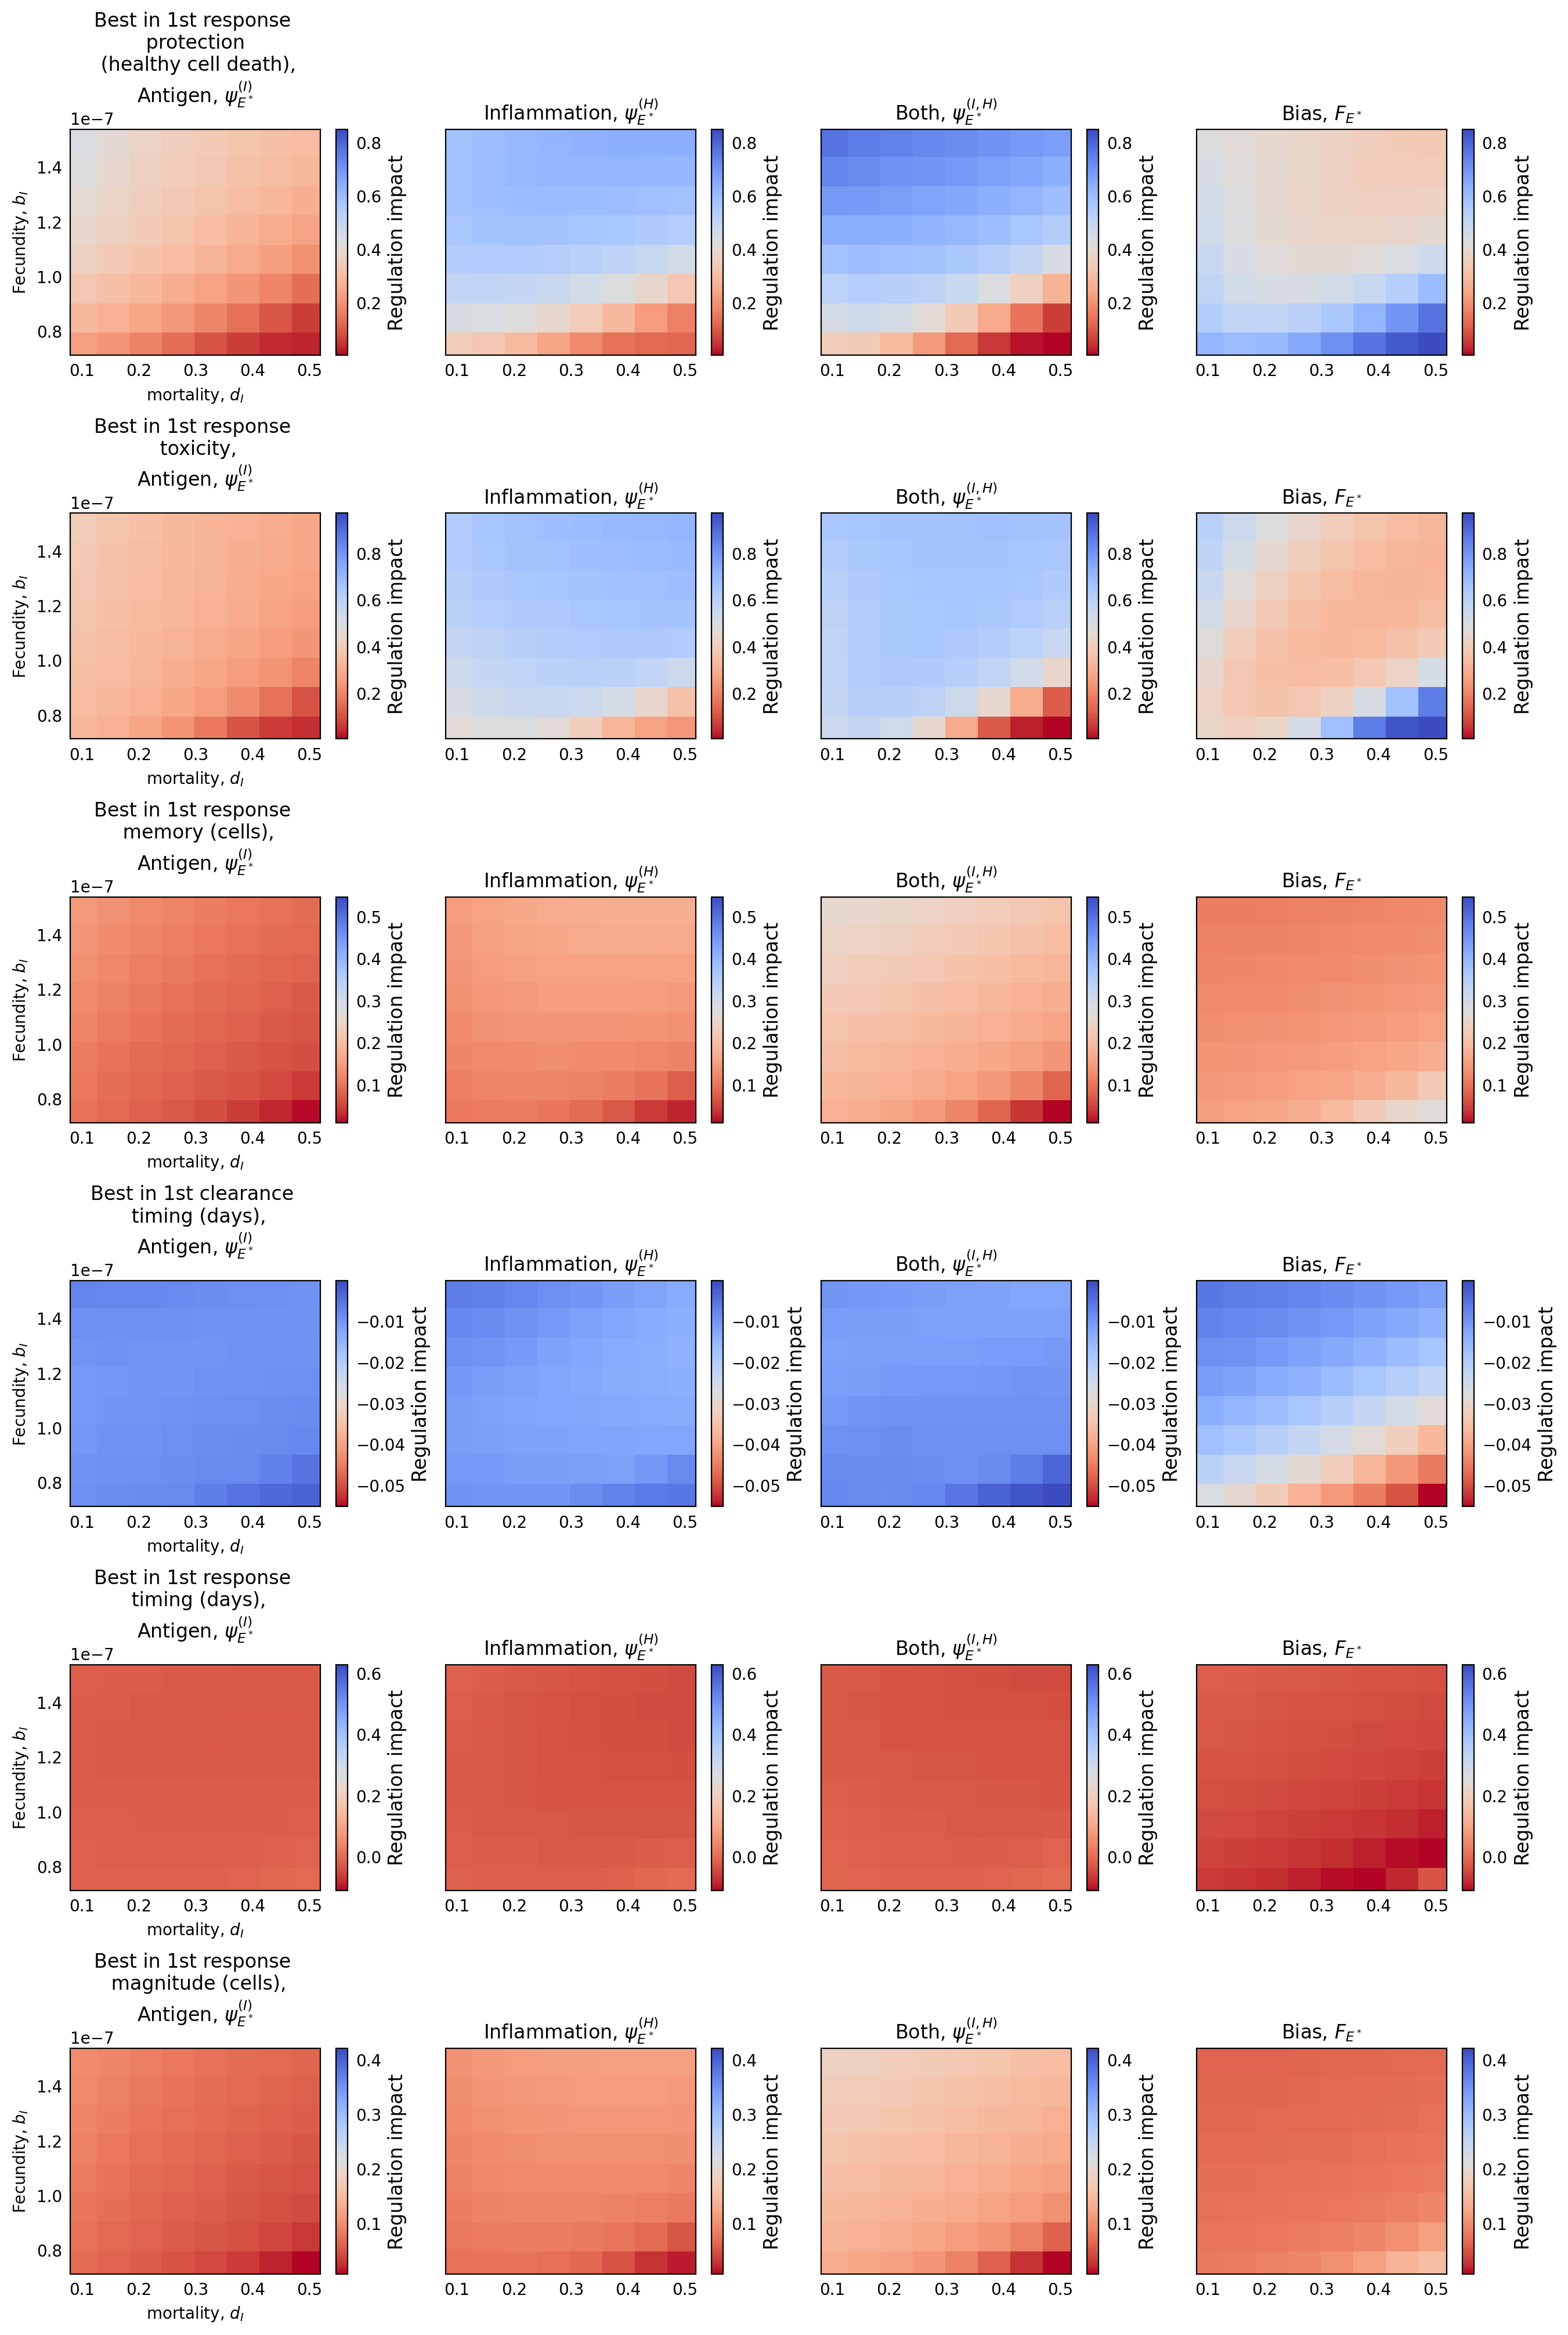

In [51]:
# Regulation of highest ranking networks
plots = [[vir_vars[1], vir_vars[0]], [vir_vars[1], vir_vars[2]], [vir_vars[0], vir_vars[2]]]
plot_labels = [["Antigenicity, "+r"$K_{I,E}$", "mortality, "+r"$d_{I}$"], ["Antigenicity, "+r"$K_{I,E}$", "Fecundity, "+r"$b_{I}$"], ["mortality, "+r"$d_{I}$", "Fecundity, "+r"$b_{I}$"]]

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    for q, plot in enumerate(plots):
        
        x_varname, y_varname = plot[0], plot[1]
        fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                                  figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='row', sharey='row')
    
        psi_IH = np.zeros(num_modules)
        bias = np.zeros(num_modules)
        
        for i, category in enumerate(perf_labels):
            vir_data_mean = impact_data.loc[(impact_data['perf_index'] == i)].groupby(plot, as_index=False).mean() #*(np.max(np.abs(df_perf_overall[reg_and] - psi_IH), axis =1) == 0)*(np.max(np.abs(df_perf_overall[reg_bias] - bias), axis =1) == 0), reg + vir_vars + [x_varname, 'p_potential_harm', 'perf_index']]

            for j, p in enumerate(["Antigen", "Inflammation", "Both", "Bias"]):
                z_varname = reg_choice[j]
                z_label = p+", "+module_reg_labels[reg_choice_label][j]
                
                im = axs[i, j].scatter(1/vir_data_mean[x_varname] if x_varname == 'K_IE' else vir_data_mean[x_varname],
                                             1/vir_data_mean[y_varname] if y_varname == 'K_IE' else vir_data_mean[y_varname],
                                  marker ='s', s = 450, c = vir_data_mean[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                                  norm = mpl.colors.Normalize(vmin= np.amin(vir_data_mean[reg]), vmax= np.amax(vir_data_mean[reg])))

                if x_varname == 'K_IE':
                    axs[i, j].semilogx()
                if y_varname == 'K_IE':
                    axs[i, j].semilogy()
                    
                axs[i, j].minorticks_off()
                axs[i, j].set_title((r'Best in '+perf_labels[i]+',\n' if j == 0 else '') + z_label, fontsize = 12.0)

                cb = fig_c.colorbar(im, ax=axs[i, j], orientation='vertical', shrink = 1.0, pad = 0.05)
                cb.set_label(r'Regulation impact', fontsize = 12)
                
        fig_c.subplots_adjust(wspace=.20, hspace=0.70)
        
        for k, ax in enumerate(axs.flat):
            if k % (2*num_modules) == 0:
                ax.set_xlabel(plot_labels[q][0], fontsize = 10)
                ax.set_ylabel(plot_labels[q][1], fontsize = 10)
    
        plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-regulation_by_performance_'+x_varname+'-'+y_varname+'_phase_dgram'+'.png', dpi=300, bbox_inches="tight")
        del vir_data_mean

In [ ]:
# Performance change due to bias
x_varname= key_var
fig_c, axs = plt.subplots(num_categories, 2*num_modules, figsize=(num_modules*num_categories, np.maximum(3.5, num_modules)*num_categories), sharex='row', sharey=False)

psi_IH = np.zeros(num_modules)
bias = np.zeros(num_modules)

for i, category in enumerate(perf_labels):
    var = perf_vars[i]
    data = df_perf.loc[(df_perf['perf_index'] == 0)*(np.max(np.abs(df_perf[reg_and] - psi_IH), axis =1) == 0), reg + vir_vars + [var, x_varname, 'perf_index']]
    up_data = data.loc[np.sum(np.abs(data[reg_bias + reg_and]), axis =1) == 0]
    
    for j, p in enumerate(reg_bias):
        const_regs = []
        for x in reg_bias:
            if x != p:
                const_regs.append(x)
                
        for u, sign in enumerate(['>','<']):
            label = reg_bias_label[j]+ " "+ sign +" 0.0"

            if sign == '>':
                p_data = data.loc[(np.sum(np.abs(data[const_regs]), axis = 1) == 0)*(data[p] == 1)]
            elif sign == '<':
                p_data = data.loc[(np.sum(np.abs(data[const_regs]), axis = 1) == 0)*(data[p] == -1)]

            y = 100*(p_data[var].to_numpy() - up_data[var].to_numpy())/up_data[var].to_numpy()
            x = p_data[x_varname].to_numpy()
            z = (1/p_data['K_IE']).to_numpy()

            im = axs[i, 2*j + u].scatter(x, y,
                              marker ='s', s = 20, c = z, cmap='coolwarm_r', edgecolors = 'None', norm=mpl.colors.LogNorm())
    
            #axs[i, 2*j + u].semilogx()
            axs[i, 2*j + u].set_yscale("symlog")
            axs[i, 2*j + u].set_title((perf_labels[i] if (j + u) == 0 else '') + '\n' + label, fontsize = 10.0)
            axs[i, 2*j + u].tick_params(axis='both', which='major', labelsize=8)
            axs[i, 2*j + u].axhline(y = 0.0, color = 'k', linestyle = '--')
        
fig_c.subplots_adjust(wspace=.30, hspace=1.0)
cb = fig_c.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.025)
cb.set_label(r'Anigenicity, $K_{I,E}^{-1}$', fontsize = 12)

for k, ax in enumerate(axs.flat):
    if k % (2*len(bias)) == 0:
        ax.set_xlabel(key_var_label, fontsize = 10)
        ax.set_ylabel(r'%$\Delta$'+ ' Performance', fontsize = 10)
        
plt.savefig('_figs/'+comment+'-perturb_bias_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# Performance change due to bias
x_varname= key_var
fig_c, axs = plt.subplots(num_categories, 2*num_modules, figsize=(num_modules*num_categories, np.maximum(3.5, num_modules)*num_categories), sharex='row', sharey=False)

psi_IH = np.zeros(num_modules)
bias = np.zeros(num_modules)

for i, category in enumerate(perf_labels):
    var = perf_vars[i]
    data = df_perf.loc[(df_perf['perf_index'] == 0)*(np.max(np.abs(df_perf[reg_bias] - bias), axis =1) == 0), reg + vir_vars + [var, x_varname, 'perf_index']]
    up_data = data.loc[np.sum(np.abs(data[reg_and + reg_bias]), axis = 1) == 0]
    
    for j, p in enumerate(reg_and):
        const_regs = []
        for x in reg_and:
            if x != p:
                const_regs.append(x)
                
        for u, sign in enumerate(['>','<']):
            label = reg_and_label[j]+ " "+ sign +" 0.0"

            if sign == '>':
                p_data = data.loc[(np.sum(np.abs(data[const_regs]), axis = 1) == 0)*(data[p] == 1)]
            elif sign == '<':
                p_data = data.loc[(np.sum(np.abs(data[const_regs]), axis = 1) == 0)*(data[p] == -1)]

            y = 100*(p_data[var].to_numpy() - up_data[var].to_numpy())/up_data[var].to_numpy()
            x = p_data[x_varname].to_numpy()
            z = (1/p_data['K_IE']).to_numpy()

            im = axs[i, 2*j + u].scatter(x, y, 
                              marker ='s', s = 20, c = z, cmap='coolwarm_r', edgecolors = 'None', norm=mpl.colors.LogNorm())
    
            #axs[i, 2*j + u].semilogx()
            axs[i, 2*j + u].set_yscale("symlog")
            axs[i, 2*j + u].set_title((perf_labels[i] if (j + u) == 0 else '') + '\n' + label, fontsize = 10.0)
            axs[i, 2*j + u].tick_params(axis='both', which='major', labelsize=8)
            axs[i, 2*j + u].axhline(y = 0.0, color = 'k', linestyle = '--')
        
fig_c.subplots_adjust(wspace=.30, hspace=1.0)
cb = fig_c.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.025)
cb.set_label(r'Anigenicity, $K_{I,E}^{-1}$', fontsize = 12)

for k, ax in enumerate(axs.flat):
    if k % (2*len(bias)) == 0:
        ax.set_xlabel(key_var_label, fontsize = 10)
        ax.set_ylabel(r'%$\Delta$'+ ' Performance', fontsize = 10)
        
plt.savefig('_figs/'+comment+'-perturb_logic_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# # Performance change relative to competition model
# x_varname= key_var
# fig_c, axs = plt.subplots(num_categories, 2*len(bias) + 1, figsize=(num_modules*num_categories, 1.75*num_modules*(2*len(bias) + 1)), sharex='row', sharey='row')

# psi_IH = np.array([0.0, 0.0])
# bias = np.array([0.0, 0.0])

# for i, category in enumerate(perf_labels):
#     var = perf_vars[i]
#     comp_index = 3 if 'NM-EM' in comment else 0
#     data = df_perf.loc[(df_perf['perf_index'] == comp_index)*(np.max(np.abs(df_perf[reg_and] - psi_IH), axis =1) == 0), reg + vir_vars + [var, x_varname, 'perf_index']]
#     comp_data_opt = comp_model_mean_df.loc[comp_model_mean_df.groupby(vir_vars + reg_and + reg_bias, as_index=False)[perf_vars[comp_index]].idxmax()[perf_vars[comp_index]]]
#     comp_data_select = comp_data_opt[(np.max(np.abs(comp_data_opt[reg_and] - psi_IH), axis =1) == 0)*(np.max(np.abs(comp_data_opt[reg_bias] - bias), axis =1) == 0)]
    
#     for j, p in enumerate([reg_bias_label[0]+ " = 0.0, " + reg_bias_label[1]+ " = 0.0",
#                            reg_bias_label[0]+ " < 0.0, " + reg_bias_label[1]+ " = 0.0",
#                            reg_bias_label[0]+ " > 0.0, " + reg_bias_label[1]+ " = 0.0",
#                            reg_bias_label[0]+ " = 0.0, " + reg_bias_label[1]+ " < 0.0",
#                            reg_bias_label[0]+ " = 0.0, " + reg_bias_label[1]+ " > 0.0"]):
#         z_label = p

#         if j == 0:
#             p_data = data.loc[(data[reg_bias[1]] == 0)*(data[reg_bias[0]] == 0)]
#         elif j == 1:
#             p_data = data.loc[(data[reg_bias[1]] == 0)*(data[reg_bias[0]] < 0)]
#         elif j == 2:
#             p_data = data.loc[(data[reg_bias[1]] == 0)*(data[reg_bias[0]] > 0)]
#         elif j == 3:
#             p_data = data.loc[(data[reg_bias[1]] < 0)*(data[reg_bias[0]] == 0)]
#         elif j == 4:
#             p_data = data.loc[(data[reg_bias[1]] > 0)*(data[reg_bias[0]] == 0)]

#         # p_data.sort_values(by=[key_var], inplace=True)
            
#         y = p_data[var].to_numpy() - comp_data_select[var].to_numpy()
#         x = p_data[x_varname].to_numpy()
#         z = (1/p_data['K_IE']).to_numpy()

#         im = axs[i, j].scatter(x, y, 
#                           marker =reg_markers[0], s = 20, c = z, cmap='coolwarm_r', linewidths=0.2, edgecolors = 'k', norm=mpl.colors.LogNorm())

#         # b, m = np.polyfit(x, y, 1)
#         # axs[i, j].plot(x, b + m * x, 'k--', label = 'trend line', zorder = 0)

#         axs[i, j].semilogx()
#         axs[i, j].set_title((r'$\Delta$'+("Memory" if 'NM-EM' in comment else 'Utility ') + 'rel. comp. model:\n' if j + i == 0 else '') + p, fontsize = 10.0)
        
# fig_c.subplots_adjust(wspace=.25, hspace=0.85)
# cb = fig_c.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.025)
# cb.set_label(r'Anigenicity, $K_{I,E}^{-1}$', fontsize = 12)

# for k, ax in enumerate(axs.flat):
#     if k % (2*len(bias) + 1) == 0:
#         ax.set_xlabel("Antigen detectability over harm, \n"+r"$\frac{b_I\times S(0) - d_I}{d_I\times K_{I,E}}$", fontsize = 10)
#         ax.set_ylabel(perf_labels[k // (2*len(bias) + 1)], fontsize = 10)
        
# plt.savefig('_figs/'+comment+'-perturb_competition-model_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# # Regulation of highest ranking networks
# x_varname= key_var

# fig_c, axs = plt.subplots(num_categories, num_psis*num_modules, figsize=(num_categories*num_psis*num_modules, num_categories*num_psis*num_modules), 
#                           sharex='row', sharey=True)

# for i, category in enumerate(perf_labels):
#     vir_data_mean = clustered_mean_df.loc[(clustered_mean_df[category] == 1)*(np.max(clustered_mean_df[module_reg['Ediv']], axis = 1) > 0), 
#     reg + vir_vars + [x_varname]].groupby(vir_vars, as_index=False).mean()
#     vir_data_std = clustered_mean_df.loc[(clustered_mean_df[category] == 1)*(np.max(clustered_mean_df[module_reg['Ediv']], axis = 1) > 0),
#     reg + vir_vars + [x_varname]].groupby(vir_vars, as_index=False).std()

#     for y in np.arange(0, num_modules):
#         for j, p in enumerate(["Antigen", "Inflammation", "Both", "Bias"]):
#             z_varname = reg[num_psis*y + j]
#             z_label = p+", "+reg_label[y*num_psis + j]

#             im = axs[i, num_psis*y + j].scatter(vir_data_mean[x_varname], vir_data_mean[z_varname], 
#                               marker =reg_markers[0], s = 50, c = 1/vir_data_mean['K_IE'], cmap='coolwarm_r', label = z_label, linewidths=0.2, edgecolors = 'k', norm=mpl.colors.LogNorm())
            
#             axs[i, num_psis*y + j].semilogx()
#             axs[i, num_psis*y + j].axhline(y = 0.0, color = 'k', linestyle = '--')
#             axs[i, num_psis*y + j].set_title((r'Top $0.1$% in '+perf_labels[i]+',\n' if num_psis*y + j == 0 else '') + z_label, fontsize = 10.0)
        

# #axs[0,-1].legend(loc='center right', bbox_to_anchor=(2.55, 0.5), fontsize = 12)
# fig_c.subplots_adjust(wspace=.25, hspace=0.5)
# cb = fig_c.colorbar(im, ax=axs, orientation='vertical', shrink = 0.75, pad = 0.025)
# cb.set_label(r'Anigenicity, $K_{I,E}^{-1}$', fontsize = 12)

# for k, ax in enumerate(axs.flat):
#     if k % (num_psis*num_modules) == 0:
#         ax.set_xlabel("Antigen detectability over harm, \n"+r"$\frac{b_I\times S(0) - d_I}{d_I\times K_{I,E}}$", fontsize = 10)
#         ax.set_ylabel("Regulation weight", fontsize = 10)
        
# plt.savefig('_figs/'+comment+'-regulation_trends_by_performance'+'.png', dpi=300, bbox_inches="tight")

### (b) Impact of cell fate modules on the immune response

In [ ]:
# Impactfulness of networks
x_varname= key_var
fig_j, axs = plt.subplots(num_categories, num_modules, figsize=(num_modules*np.maximum(3.5, num_modules), num_categories*np.maximum(3.5, num_modules)), sharex='row', sharey='row')

for y in np.arange(0, num_modules):
    vir_data_mean = clustered_mean_df[reg + vir_vars + [x_varname] + perf_vars].groupby(vir_vars + [x_varname] + reg[num_psis*y:num_psis*(y+1)], as_index=False).mean()
    data_std = vir_data_mean.groupby(vir_vars + [x_varname], as_index=False).std()
    data_mean = vir_data_mean.groupby(vir_vars + [x_varname], as_index=False).mean()
    data_max = vir_data_mean.groupby(vir_vars + [x_varname], as_index=False).max() - data_mean
    data_min = data_mean - vir_data_mean.groupby(vir_vars + [x_varname], as_index=False).max()
    
    
    for i, category in enumerate(perf_labels):
        y_varname = perf_vars[i]

        im = axs[i, y].scatter(data_std[x_varname], data_std[y_varname]/data_mean[y_varname], 
                              marker ='s', s = 50, c = data_mean['b_I']*data_mean['S_0'] - data_mean['d_I'], cmap='coolwarm_r', edgecolors = 'None', norm=mpl.colors.LogNorm())
        axs[i, y].scatter(data_mean[x_varname], np.maximum(data_max[y_varname],data_min[y_varname])/data_mean[y_varname], marker = '_', 
                            s = 50, c = data_mean['b_I']*data_mean['S_0'] - data_mean['d_I'], cmap='coolwarm_r', linewidths=2.5, label = r'Largest observed effect' if (i == 0)*(y == num_modules -1) else '')
        #axs[i, y].semilogx()
        axs[i, y].semilogy()
        axs[i, y].set_title((perf_labels[i]+'\n' if y == 0 else '') + ', '.join(reg_label[num_psis*y:num_psis*(y+1)]), fontsize = 10.0)
        

axs[0,-1].legend(loc='center right', bbox_to_anchor=(2.5, 0.5), fontsize = 12)
fig_j.subplots_adjust(wspace=.25, hspace=.85)
cb = fig_j.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.05)
cb.set_label("Effective replication, \n"+r"$b_I\times S(0) - d_I$", fontsize = 12)

for k, ax in enumerate(axs.flat):
    if k % (num_modules) == 0:
        ax.set_xlabel(key_var_label, fontsize = 10)
        ax.set_ylabel(r"$\frac{\text{Standard deviation of Marginal}}{\text{Mean of Marginal}}$", fontsize = 10)
        
plt.savefig('_figs/'+comment+'-modularity_by_performance'+'.png', dpi=300, bbox_inches="tight")

del vir_data_mean

### (c) Dependence of performance on modules and architectures

In [ ]:
fig_d, axs = plt.subplots(num_categories, num_modules, figsize=(np.maximum(num_modules,4)*num_modules*0.75, num_categories*np.maximum(num_modules,4)*0.75), sharex=True, sharey='row')

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    psi_IH = 0.0
    bias = 0.0
    x_varname = key_var #'antigenicity_over_harm', 'p_potential_harm'
    unreg_perf = clustered_mean_df.loc[(clustered_mean_df[reg_choice[0]] == 0.0)*(clustered_mean_df[reg_choice[1]] == 0.0)*(clustered_mean_df[reg_choice[2]] == psi_IH),
                    reg + vir_vars + [x_varname] + perf_vars].groupby(vir_vars + [x_varname, reg_choice[3]], as_index=False).mean()
    unreg_perf.sort_values(by=[x_varname], inplace=True)
    
    for p, var in enumerate(perf_vars):
        
        im = axs[p, module_index].scatter(unreg_perf.loc[(unreg_perf[reg_choice[3]] == 0.0)][x_varname], unreg_perf.loc[(unreg_perf[reg_choice[3]] == 0.0)][var], label = reg_label[num_psis*module_index + 3] +' = 0',
                                      marker ='s', s = 25, c = 1/unreg_perf.loc[(unreg_perf[reg_choice[3]] == 0.0)]['K_IE'], cmap='coolwarm_r', edgecolors = 'None', norm=mpl.colors.LogNorm(), zorder = 0)

        axs[p, module_index].scatter(unreg_perf.loc[(unreg_perf[reg_choice[3]] == 1.0)][x_varname], unreg_perf.loc[(unreg_perf[reg_choice[3]] == 1.0)][var], label = reg_label[num_psis*module_index + 3] +' = 1.0',
                                      marker ='^', color = 'none', linewidths=0.25, edgecolors = 'r', s = 10, zorder = 0)

        axs[p, module_index].set_title(' = 0.0, '.join(reg_label[num_psis*module_index:num_psis*(module_index) + 2]) + " = 0.0, \n" + ' = 0.0, '.join(reg_label[num_psis*module_index + 2:num_psis*(module_index+1)]) + " = 0.0" , 
                                       fontsize = 8.0)
        axs[p, module_index].tick_params(axis='both', which='major', labelsize=8)
                                       
        # if x_varname == key_var:
        #     axs[p, module_index].semilogx()
        if 'memory' in perf_labels[p] or 'toxicity' in perf_labels[p] or 'magnitude' in perf_labels[p] or 'protection' in perf_labels[p]:
            axs[p, module_index].set_yscale("symlog")

axs[0,-1].legend(loc='center right', bbox_to_anchor=(2.5, 0.0), fontsize = 12)
fig_d.subplots_adjust(wspace=.35, hspace=0.65)
cb = fig_d.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.05)
cb.set_label("Antigenicity, "+r"$K_{I,E}^{-1}$", fontsize = 12)
        
for k, ax in enumerate(axs.flat):
    if k % num_modules == 0:
        ax.set_ylabel(perf_labels[k// num_modules], fontsize = 9)
        if x_varname == key_var:
            ax.set_xlabel(key_var_label, fontsize = 9)
        elif x_varname == 'p_potential_harm':
            ax.set_xlabel("Harm \n from non-detection", fontsize = 9)
                
plt.savefig('_figs/'+comment+'-'+'_perf_no_reg_sctr.png', dpi=300, bbox_inches="tight")

In [ ]:
# Regulation of networks versus performance

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    psi_Is = np.unique(clustered_mean_df[reg_choice[0]].to_numpy(), axis = 0)
    psi_Hs = np.unique(clustered_mean_df[reg_choice[1]].to_numpy(), axis = 0)
    psi_IH = 0.0
    bias = 0.0
    x_varname = key_var #'antigenicity_over_harm', 'p_potential_harm'
    unreg_perf = clustered_mean_df.loc[(clustered_mean_df[reg_choice[0]] == 0.0)*(clustered_mean_df[reg_choice[1]] == 0.0)*(clustered_mean_df[reg_choice[2]] == psi_IH)*(clustered_mean_df[reg_choice[3]] == bias),
                    reg + vir_vars + [x_varname] + perf_vars].groupby(vir_vars + [x_varname, reg_choice[3]], as_index=False).mean()
    unreg_perf.sort_values(by=[x_varname], inplace=True)
    
    for p, var in enumerate(perf_vars):
    
        fig_d, axs = plt.subplots(len(psi_Is), len(psi_Hs), figsize=(np.maximum(len(psi_Is), 4)**2/2, np.maximum(len(psi_Is), 4)**2/2), sharex='row', sharey=True)
        
        for i, psi_I in enumerate(psi_Is):
            for j, psi_H in enumerate(psi_Hs):
                reg_data_mean = clustered_mean_df.loc[(clustered_mean_df[reg_choice[0]] == psi_I)*(clustered_mean_df[reg_choice[1]] == psi_H)*(clustered_mean_df[reg_choice[2]] == psi_IH)*(clustered_mean_df[reg_choice[3]] == bias)].groupby(vir_vars + [x_varname], as_index=False).mean()
                reg_data_mean.sort_values(by=[x_varname], inplace=True)

                if bias == 0:
                    im = axs[i, j].scatter(reg_data_mean[x_varname], 100*(reg_data_mean[var].values - unreg_perf[var].values)/np.abs(unreg_perf[var].values), label = reg_label[num_psis*module_index + 2] +' = '+str(np.round(psi_IH,2)) + ', '+ reg_label[num_psis*module_index + 3] +' = '+str(np.round(bias,2)),
                                          marker ='s', s = 25, c = 1/reg_data_mean['K_IE'], cmap='coolwarm_r', edgecolors = 'None', norm=mpl.colors.LogNorm(), zorder = 0)

                axs[i, j].set_title("("+str(len(psi_Hs)*i + j + 1)+") "+reg_label[module_index*num_psis] +' = '+str(psi_I) +', '+reg_label[module_index*num_psis + 1] +' = '+str(psi_H) +',\n '+reg_label[module_index*num_psis + 2] +' = '+str(psi_IH) , fontsize = 8.0)
                axs[i, j].tick_params(axis='both', which='major', labelsize=8)
                axs[i, j].axhline(y = 0.0, color = 'k', linestyle = '--')
                # if x_varname == key_var:
                #     axs[i, j].semilogx()
                if 'memory' in perf_labels[p] or 'toxicity' in perf_labels[p] or 'response' in perf_labels[p] or 'protection' in perf_labels[p]:
                    axs[i, j].set_yscale("symlog")
                
        fig_d.subplots_adjust(wspace=.35, hspace=0.87)
        cb = fig_d.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.05)
        cb.set_label("Antigenicity, "+r"$K_{I,E}^{-1}$", fontsize = 12)
        axs[0,-1].legend(loc='center right', bbox_to_anchor=(4.0, 0.0), fontsize = 12)
        
        for k, ax in enumerate(axs.flat):
            if k % len(psi_Hs) == 0:
                ax.set_ylabel(r'%$\Delta$ ' + perf_labels[p], fontsize = 9)
                if x_varname == key_var:
                    ax.set_xlabel(key_var_label, fontsize = 9)
                elif x_varname == 'p_potential_harm':
                    ax.set_xlabel("Harm \n from non-detection", fontsize = 9)
                
        plt.savefig('_figs/'+comment+'-'+reg_choice_label+'_perf_by_bias_sctr'+var+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# # Regulation of networks versus performance

# for module_index in np.arange(0, len(modules)):
#     for p, var in enumerate(perf_vars):
#         reg_choice_label = modules[module_index]
#         reg_choice = module_reg[reg_choice_label]
#         psi_Is = np.unique(clustered_mean_df[reg_choice[0]].to_numpy(), axis = 0)
#         psi_Hs = np.unique(clustered_mean_df[reg_choice[1]].to_numpy(), axis = 0)
#         psi_IHs = np.unique(clustered_mean_df[reg_choice[2]].to_numpy(), axis = 0)
#         bias = 0.0
#         x_varname = key_var #'antigenicity_over_harm', 'p_potential_harm'
        
#         unreg_perf = clustered_mean_df.loc[(clustered_mean_df[reg_choice[0]] == 0.0)*(clustered_mean_df[reg_choice[1]] == 0.0)*(clustered_mean_df[reg_choice[3]] == bias), 
#                     reg + vir_vars + [x_varname, var]].groupby(vir_vars + [x_varname, reg_choice[2]], as_index=False).mean()
#         unreg_perf.sort_values(by=[x_varname], inplace=True)
        
#         fig_d, axs = plt.subplots(len(psi_Is), len(psi_Hs), figsize=(np.maximum(len(psi_Is), 4)**2/2, np.maximum(len(psi_Is), 4)**2/2), sharex=True, sharey=True)
        
#         for i, psi_I in enumerate(psi_Is):
#             for j, psi_H in enumerate(psi_Hs):
#                 for l, psi_IH in enumerate(psi_IHs):
#                     reg_data_mean = clustered_mean_df.loc[(clustered_mean_df[reg_choice[0]] == psi_I)*(clustered_mean_df[reg_choice[1]] == psi_H)*(clustered_mean_df[reg_choice[2]] == psi_IH)*(clustered_mean_df[reg_choice[3]] == bias)].groupby(vir_vars + [x_varname], as_index=False).mean()
#                     reg_data_mean.sort_values(by=[x_varname], inplace=True)

#                     if psi_IH == 0:
#                         im = axs[i, j].scatter(reg_data_mean[x_varname].values, 100*(reg_data_mean[var].values - unreg_perf.loc[unreg_perf[reg_choice[2]] == psi_IH][var].values)/np.abs(unreg_perf.loc[unreg_perf[reg_choice[2]] == psi_IH][var].values), label = reg_label[num_psis*module_index + 2] +' = '+str(np.round(psi_IH,2)),
#                                               marker ='s', s = 25, c = 1/reg_data_mean['K_IE'], cmap='coolwarm_r', linewidths=0.2, edgecolors = 'k', norm=mpl.colors.LogNorm(), zorder = 0)
#                     # else:
#                     #     axs[i, j].scatter(reg_data_mean[x_varname].values, 100*(reg_data_mean[var].values - unreg_perf.loc[unreg_perf[reg_choice[2]] == psi_IH][var].values)/np.abs(unreg_perf.loc[unreg_perf[reg_choice[2]] == psi_IH][var].values), 
#                     #                       marker = '^' if psi_IH > 0 else 'v', color = 'none', linewidths=0.5, edgecolors = 'r', s = 10, label = reg_label[num_psis*module_index + 2] +' = '+str(np.round(psi_IH,2)))
                        
#                 axs[i, j].set_title("("+str(len(psi_Hs)*i + j + 1)+") "+reg_label[module_index*num_psis] +' = '+str(psi_I) +', '+reg_label[module_index*num_psis] +' = '+str(psi_H) +',\n '+reg_label[module_index*num_psis] +' = '+str(bias) , fontsize = 8.0)
#                 axs[i, j].axhline(y = 0.0, color = 'k', linestyle = '--')
                
#                 # if x_varname == key_var:
#                 #     axs[i, j].semilogx()
#                 if 'memory' in perf_labels[p] or 'toxicity' in perf_labels[p] or 'response' in perf_labels[p] or 'protection' in perf_labels[p]:
#                     axs[i, j].set_yscale("symlog")
                
#         fig_d.subplots_adjust(wspace=.4, hspace=0.8)
#         cb = fig_d.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.05)
#         cb.set_label("Antigenicity, "+r"$K_{I,E}^{-1}$", fontsize = 12)
#         # axs[0,-1].legend(loc='center right', bbox_to_anchor=(3.5, 0.0), fontsize = 12)
        
#         for k, ax in enumerate(axs.flat):
#             if k % len(psi_Hs) == 0:
#                 ax.set_ylabel(perf_labels[p], fontsize = 9)
#                 if x_varname == key_var:
#                     ax.set_xlabel(key_var_label, fontsize = 9)
#                 elif x_varname == 'p_potential_harm':
#                     ax.set_xlabel("Harm \n from non-detection", fontsize = 9)
                
#         plt.savefig('_figs/'+comment+'-'+reg_choice_label+'_perf_by_regulation_sctr-'+var+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# Regulation of networks versus performance

plots = [[vir_vars[1], vir_vars[0]], [vir_vars[1], vir_vars[2]], [vir_vars[0], vir_vars[2]], [vir_vars[0], vir_vars[1]]]
plot_labels = [["Antigenicity, "+r"$K_{I,E}$", "mortality, "+r"$d_{I}$"], ["Antigenicity, "+r"$K_{I,E}$", "Fecundity, "+r"$b_{I}$"], ["mortality, "+r"$d_{I}$", "Fecundity, "+r"$b_{I}$"], ["Harmfulness, "+r"$(b_{I}S_{0} - d_{I})d_{I}$", "Antigenicity, "+r"$K_{I,E}^{-1}$"]]

for module_index in np.arange(0, len(modules)):
    for p, plot in enumerate(plots):
        reg_choice_label = modules[module_index]
        reg_choice = module_reg[reg_choice_label]
        psi_Is = np.unique(clustered_mean_df[reg_choice[0]].to_numpy(), axis = 0)
        psi_Hs = np.unique(clustered_mean_df[reg_choice[1]].to_numpy(), axis = 0)
        psi_IH = 0.0
        bias = 0.0
        fig_e, axs = plt.subplots(len(psi_Is), len(psi_Hs), figsize=(len(psi_Is)**2, len(psi_Hs)**2), sharex='row', sharey=True)
        
        perf_choice = 0 if 'Ediv' in reg_choice_label else (3 if 'Nact' in reg_choice_label else 2)
        z_varname = perf_vars[perf_choice]
        if p < 3:
            avg_data = clustered_mean_df.loc[(clustered_mean_df[reg_choice[2]] == psi_IH)*(clustered_mean_df[reg_choice[3]] == bias)].groupby(plot + reg_choice, as_index=False).mean()
        else:
            avg_data = clustered_mean_df.loc[(clustered_mean_df[reg_choice[2]] == psi_IH)*(clustered_mean_df[reg_choice[3]] == bias)].groupby(vir_vars + reg_choice, as_index=False).mean()
            
        vmin, vmax = np.amin(avg_data[z_varname]), np.amax(avg_data[z_varname])
        
        for i, psi_I in enumerate(psi_Is):
            for j, psi_H in enumerate(psi_Hs):
                if 'toxicity' in category or 'timing' in perf_labels[perf_choice]:
                    reg_data_mean = clustered_mean_df.loc[(clustered_mean_df['d_I'] >= 0)*(clustered_mean_df[reg_choice[0]] == psi_I)*(clustered_mean_df[reg_choice[1]] == psi_H)*(clustered_mean_df[reg_choice[2]] == psi_IH)*(clustered_mean_df[reg_choice[3]] == bias), 
                    reg + vir_vars + [key_var, z_varname]].groupby(vir_vars, as_index=False).mean()
                else:
                    reg_data_mean = clustered_mean_df.loc[(clustered_mean_df['d_I'] >= 0)*(clustered_mean_df[reg_choice[0]] == psi_I)*(clustered_mean_df[reg_choice[1]] == psi_H)*(clustered_mean_df[reg_choice[2]] == psi_IH)*(clustered_mean_df[reg_choice[3]] == bias), 
                reg + vir_vars + [key_var, z_varname]].groupby(vir_vars, as_index=False).mean()
        
                x_varname = plot[0]
                y_varname = plot[1]

                if p < 3:
                    im = axs[i, j].scatter(reg_data_mean[x_varname], reg_data_mean[y_varname], 
                                          marker ='s', s = 1000, c = reg_data_mean[z_varname], cmap= 'coolwarm' if 'timing' in perf_labels[perf_choice] or 'toxicity' in perf_labels[perf_choice] else 'coolwarm_r', norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax) if 'timing' in perf_labels[perf_choice] else mpl.colors.SymLogNorm(linthresh=0.1, linscale=1, vmin=vmin, vmax=vmax))
                else:
                    im = axs[i, j].scatter((reg_data_mean['b_I']*reg_data_mean['S_0'] - reg_data_mean['d_I'])*reg_data_mean['d_I'], 1/reg_data_mean[y_varname], 
                                      marker ='s', s = 250, c = reg_data_mean[z_varname], cmap= 'coolwarm' if 'timing' in perf_labels[perf_choice] or 'toxicity' in perf_labels[perf_choice] else 'coolwarm_r', norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax) if 'timing' in perf_labels[perf_choice] else mpl.colors.SymLogNorm(linthresh=0.1, linscale=1, vmin=vmin, vmax=vmax))
    
        
                axs[i, j].set_title("("+str(len(psi_Hs)*i + j + 1)+") "+reg_label[module_index*num_psis] +' = '+str(psi_I) +', '+reg_label[module_index*num_psis] +' = '+str(psi_H) +',\n '+reg_label[module_index*num_psis] +' = '+str(psi_IH) +', '+reg_label[module_index*num_psis] +' = '+str(bias), 
                                    fontsize = 8.0)
                if 'K_IE' in x_varname:
                    axs[i, j].semilogx()
                if 'K_IE' in y_varname:
                    axs[i, j].semilogy()
                
        fig_e.subplots_adjust(wspace=.45, hspace=0.90)
        cb = fig_e.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.05)
        cb.set_label(("Mean " if 'toxicity' in category or 'timing' in perf_labels[perf_choice] else "Mean ") + perf_labels[perf_choice], fontsize = 12)
        
        for k, ax in enumerate(axs.flat):
            if k % len(psi_Hs) == 0:
                ax.set_ylabel(plot_labels[p][1], fontsize = 9)
                ax.set_xlabel(plot_labels[p][0], fontsize = 9)
                
        plt.savefig('_figs/'+comment+'-'+reg_choice_label+'_'+z_varname+'_by_regulation_hmap'+str(p)+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# # Regulation of networks versus performance

# fig, axs = plt.subplots(1, num_categories, figsize=(4*num_categories, 2), sharex='row', sharey='col')
# for p, var in enumerate(perf_vars):
#     n_regs = int(len(reg)/3)
#     reg_choice_label = modules[1]
#     reg_choice = module_reg[reg_choice_label]

#     x_varname = key_var
#     x_label = reg_label[y]

#     im = axs[p].scatter(comp_model_mean_df[x_varname], comp_model_mean_df[var], 
#                           marker ='o', s = 25, c = 1/comp_model_mean_df['K_IE'], cmap='coolwarm', linewidths=0.2, edgecolors = 'k', norm=mpl.colors.LogNorm())
#     #axs[p].set_title("("+str(len(psi_Hs)*i + j + 1)+") "+reg_label[3] +' = '+str(psi_I) +', '+reg_label[4] +' = '+str(psi_H), fontsize = 8.0)
#     axs[p].semilogx()
#     if 'memory' in perf_labels[p] or 'toxicity' in perf_labels[p] or 'response' in perf_labels[p]:
#         axs[p].semilogy()
            
#     fig.subplots_adjust(wspace=.45, hspace=0.90)
#     cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.75, pad = 0.05)
#     cb.set_label("Antigenicity, "+r"$K_{I,E}^{-1}$", fontsize = 12)
    
#     for k, ax in enumerate(axs.flat):
#         ax.set_ylabel(perf_labels[p], fontsize = 9)
#         if k % num_categories == 0:
#             ax.set_xlabel("Antigen detectability over harm, \n"+r"$\frac{b_I\times S(0) - d_I}{d_I\times K_{I,E}}$", fontsize = 9)
            
# plt.savefig('_figs/'+comment+'-'+reg_choice_label+'_perf_by_compmodel_sctr-'+var+'.png', dpi=300, bbox_inches="tight")

### (d) Sensitivity vs Specificity Trade-off

In [ ]:
# Regulation of networks versus performance
fig_h, axs = plt.subplots(len(perf_vars), len(reg_and + reg_bias), figsize=(len(reg_and + reg_bias)**2, len(perf_vars)**2), sharex='row', sharey='row')

# calculate sensitivity
utility_df = clustered_mean_df.groupby(reg, as_index=False).mean() #/np.mean(clustered_mean_df.loc[(np.max(np.abs(clustered_mean_df[reg]), axis = 1) == 0)][var])

# calculate specificity
risk_df = clustered_mean_df.groupby(reg, as_index=False).std()
psi_vals = np.unique(clustered_mean_df[reg].to_numpy(), axis = 0)

for p, var in enumerate(perf_vars):
    indices = [2,3,6,7,10,11,14,15]
    x = utility_df[var]
    y = risk_df[var]/np.abs(utility_df[var])
    
    for j, reg_var in enumerate(reg_and + reg_bias):
        z = utility_df[reg[indices[j]]]
        im = axs[p, j].scatter(x, y, 
                                      marker ='o', s = 10, c = z, cmap='coolwarm_r', edgecolors = 'None', alpha = 0.5,
                              norm = mpl.colors.Normalize(vmin= np.min(psi_vals[:,3]), vmax= np.max(psi_vals[:,3])))
        axs[p, j].set_title((perf_labels[p] +' \n' if j == 0 else '') + reg_label[indices[j]], fontsize = 12.0)
        axs[p, j].set_yscale("symlog")
        # if 'timing' not in perf_labels:
        #     axs[p, j].set_xscale("symlog")
                
fig_h.subplots_adjust(wspace=.40, hspace=0.65)
cb = fig_h.colorbar(im, ax=axs, orientation='vertical', shrink = 0.5, pad = 0.05)
cb.set_label(', '.join(reg_label), fontsize = 18)

for k, ax in enumerate(axs.flat):
    ax.set_ylabel("Risk", fontsize = 12)
    ax.set_xlabel("Average magnitude", fontsize = 12)
    #ax.semilogx()
        
plt.savefig('_figs/'+comment+'-'+'_utility_v_risk_by_reg_sctr-'+var+'.png', dpi=300, bbox_inches="tight")
del utility_df
del risk_df

In [ ]:
# Regulation of networks versus performance
fig_h, axs = plt.subplots(1, len(perf_vars[1:]), figsize=(len(perf_vars[1:])**2/2, 3.0), sharex=True, sharey=True)

# compute risk-utility
utility_df = clustered_mean_df.groupby(reg, as_index=False).mean() #/np.mean(clustered_mean_df.loc[(np.max(np.abs(clustered_mean_df[reg]), axis = 1) == 0)][var])
risk_df = clustered_mean_df.groupby(reg, as_index=False).std()

for p, var in enumerate(perf_vars[1:]):
    indices = [2,3,6,7,10,11,14,15]
    x = utility_df[perf_vars[0]]
    y = risk_df[perf_vars[0]]/np.abs(x)
    z = utility_df[var]
    
    im = axs[p].scatter(x, y, marker ='o', s = 2.5, c = z, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))

    axs[p].set_yscale("log")
    axs[p].set_xscale("log")

    # make inset figure with top 95%
    cutoff = np.quantile(utility_df[perf_vars[0]], 0.95)
    xins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]
    yins = risk_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]/np.abs(xins)
    zins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][var]

    axins = inset_axes(axs[p], width="30%", height="40%", loc=3, borderpad=0.5)
    axins.scatter(xins, yins, marker ='o', s = 2.5, c = zins, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axins.tick_params(labelleft=False, labelbottom=False)

    cb = fig_h.colorbar(im, ax=axs[p], orientation='horizontal', shrink = 1.0, pad = 0.3)
    cb.set_label(perf_labels[p + 1], fontsize = 10)
                
fig_h.subplots_adjust(wspace=.3, hspace=0.65)

for k, ax in enumerate(axs.flat):
    if k == 0:
        ax.set_ylabel("Coef.\n of variation", fontsize = 12)
        ax.set_xlabel("Average utility", fontsize = 12)
        
plt.savefig('_figs/'+comment+'-'+'_utility_v_risk_by_perf_sctr.png', dpi=300, bbox_inches="tight")
del utility_df
del risk_df

In [ ]:
# Regulation of networks versus performance
fig_h, axs = plt.subplots(1, num_modules, figsize=(num_modules**2, 3.0), sharex=True, sharey=True)

# compute risk-utility
clustered_mean_df = clustered_mean_df.sample(frac=1).reset_index(drop=True)
utility_df = clustered_mean_df.groupby(reg, as_index=False).mean() #/np.mean(clustered_mean_df.loc[(np.max(np.abs(clustered_mean_df[reg]), axis = 1) == 0)][var])
risk_df = clustered_mean_df.groupby(reg, as_index=False).std()

for p, var in enumerate(reg_and):
    indices = [2,3,6,7,10,11,14,15]
    x = utility_df[perf_vars[0]]
    y = risk_df[perf_vars[0]]/np.abs(utility_df[perf_vars[0]])
    
    z = utility_df[var]
    im = axs[p].scatter(x, y, marker ='o', s = 2.5, c = z, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axs[p].set_yscale("log")
    axs[p].set_xscale("log")

    # make inset figure with top 95%
    cutoff = np.quantile(utility_df[perf_vars[0]], 0.95)
    xins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]
    yins = risk_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]/np.abs(xins)
    zins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][var]

    axins = inset_axes(axs[p], width="30%", height="40%", loc=3)
    axins.scatter(xins, yins, marker ='o', s = 2.5, c = zins, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axins.tick_params(labelleft=False, labelbottom=False)

    cb = fig_h.colorbar(im, ax=axs[p], orientation='horizontal', shrink = 1.0, pad = 0.3)
    cb.set_label(reg_and_label[p], fontsize = 10)
                
fig_h.subplots_adjust(wspace=.3, hspace=0.65)

for k, ax in enumerate(axs.flat):
    if k == 0:
        ax.set_ylabel("Coef.\n of variation", fontsize = 12)
        ax.set_xlabel("Average utility", fontsize = 12)
        
plt.savefig('_figs/'+comment+'-'+'_utility_v_risk_by_logic_sctr.png', dpi=300, bbox_inches="tight")
del utility_df
del risk_df

In [ ]:
# Regulation of networks versus performance
fig_h, axs = plt.subplots(1, num_modules, figsize=(num_modules**2, 3.0), sharex=True, sharey=True)

# compute risk-utility
utility_df = clustered_mean_df.groupby(reg, as_index=False).mean() #/np.mean(clustered_mean_df.loc[(np.max(np.abs(clustered_mean_df[reg]), axis = 1) == 0)][var])
risk_df = clustered_mean_df.groupby(reg, as_index=False).std()

for p, var in enumerate(reg_bias):
    indices = [2,3,6,7,10,11,14,15]
    x = utility_df[perf_vars[0]]
    y = risk_df[perf_vars[0]]/np.abs(utility_df[perf_vars[0]])
    
    z = utility_df[var]
    im = axs[p].scatter(x, y, marker ='o', s = 2.5, c = z, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axs[p].set_yscale("log")
    axs[p].set_xscale("log")

    # make inset figure with top 95%
    cutoff = np.quantile(utility_df[perf_vars[0]], 0.95)
    xins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]
    yins = risk_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]/np.abs(xins)
    zins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][var]

    axins = inset_axes(axs[p], width="30%", height="40%", loc=3)
    axins.scatter(xins, yins, marker ='o', s = 2.5, c = zins, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axins.tick_params(labelleft=False, labelbottom=False)

    cb = fig_h.colorbar(im, ax=axs[p], orientation='horizontal', shrink = 1.0, pad = 0.3)
    cb.set_label(reg_bias_label[p], fontsize = 10)
                
fig_h.subplots_adjust(wspace=.3, hspace=0.65)

for k, ax in enumerate(axs.flat):
    if k == 0:
        ax.set_ylabel("Coef.\n of variation", fontsize = 12)
        ax.set_xlabel("Average utility", fontsize = 12)
        
plt.savefig('_figs/'+comment+'-'+'_utility_v_risk_by_bias_sctr.png', dpi=300, bbox_inches="tight")
del utility_df
del risk_df

In [ ]:
# Regulation of networks versus performance
fig_h, axs = plt.subplots(1, num_categories, figsize=(num_categories**2/2, 3), sharex=True, sharey=True)

# calculate risk-utility
utility_df = clustered_mean_df.groupby(reg, as_index=False).mean() #/np.mean(clustered_mean_df.loc[(np.max(np.abs(clustered_mean_df[reg]), axis = 1) == 0)][var])
risk_df = clustered_mean_df.groupby(reg, as_index=False).std()


# calculate specificity
num_cpu = 36
psi_vals = utility_df[reg].values

def model(df, psi, x, y):
    input = df.loc[(np.sum(np.abs(df[reg] - psi), axis = 1) == 0)]
    Y = input[y].values
    X = input[x].values
    lr = LinearRegression()
    lr.fit(X, Y)

    specificity = np.squeeze(lr.coef_/np.mean(input[y]))
    
    return specificity.tolist() +  psi.tolist()

# specificity_data = np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(len(clustered_mean_df) // len(virs),1))(delayed(model)(df = clustered_mean_df, psi = psi, x = [key_var], y = perf_vars)
#                                                     for psi in psi_vals))

for p, var in enumerate(perf_vars):
    indices = [2,3,6,7,10,11,14,15]
    x = utility_df[perf_vars[0]]
    y = risk_df[perf_vars[0]]/np.abs(utility_df[perf_vars[0]])
    
    z = specificity_data[:, p]
    im = axs[p].scatter(x, y, marker ='o', s = 2.5, c = z, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axs[p].set_yscale("log")
    axs[p].set_xscale("log")

    # make inset figure with top 95%
    cutoff = np.quantile(utility_df[perf_vars[0]], 0.95)
    xins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]
    yins = risk_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]/np.abs(xins)
    zins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][var]

    axins = inset_axes(axs[p], width="30%", height="40%", loc=3)
    axins.scatter(xins, yins, marker ='o', s = 2.5, c = zins, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axins.tick_params(labelleft=False, labelbottom=False)

    cb = fig_h.colorbar(im, ax=axs[p], orientation='horizontal', shrink = 1.0, pad = 0.3)
    cb.set_label("Specificity of " + perf_labels[p], fontsize = 10)
                
fig_h.subplots_adjust(wspace=.3, hspace=0.65)

for k, ax in enumerate(axs.flat):
    if k == 0:
        ax.set_ylabel("Coef.\n of variation", fontsize = 12)
        ax.set_xlabel("Average utility", fontsize = 12)
        
plt.savefig('_figs/'+comment+'-'+'_utility_v_risk_by_sensitivity_sctr-'+var+'.png', dpi=300, bbox_inches="tight")

### (e) Response in Autoimmune scenarios

In [ ]:
# Load data from 2nd infections
infection_type = 'prim'
reg_model = ''
runs = '-1-'
comment = "auto-Nact-Ediv-vir"

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'
#d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/std/processed_data'+runs+'runs'+'-'+comment+'.pkl'


autoimmune_mean_df = pd.read_pickle(d_mean)
autos = np.unique(autoimmune_mean_df[['d_S','d_I','K_IE', 'b_I']].to_numpy(), axis = 0) #vir_prop[:, 0:2] 
n_autos = len(autos)
#std_df = pd.read_pickle(d_std)

with pd.option_context('display.max_columns', None):
    display(autoimmune_mean_df)

In [ ]:
# Regulation of networks versus performance
reg_choice_label = "Nact"
reg_choice = module_reg[reg_choice_label]
module_index = modules.index(reg_choice_label)
auto_virs = np.unique(autoimmune_mean_df[['d_S','d_I','K_IE', 'b_I']].to_numpy(), axis = 0)

for p, var in enumerate(perf_vars):

    fig_k, axs = plt.subplots(1, len(reg_choice), figsize=(len(reg_choice)**2, len(reg_choice)*2/3), sharex=True, sharey=True)

    x_data = autoimmune_mean_df.loc[(np.sum(autoimmune_mean_df[['d_S','d_I','K_IE', 'b_I']] - auto_virs[0], axis = 1) == 0)]#.groupby(reg_choice, as_index=False).mean()
    y_data = autoimmune_mean_df.loc[(np.sum(autoimmune_mean_df[['d_S','d_I','K_IE', 'b_I']] - auto_virs[1], axis = 1) == 0)]#.groupby(reg_choice, as_index=False).mean()

    x_label = perf_labels[p]+"\n"+r"$d_S =$ "+str(auto_virs[0,0] + auto_virs[0,1])+",\n"+r"$K_{S,E} =$ "+str(int(auto_virs[0,2]))
    y_label = perf_labels[p]+"\n"+r"$d_S =$ "+str(auto_virs[1,0] + auto_virs[1,1])+",\n"+r"$K_{S,E} =$ "+str(int(auto_virs[1,2]))

    for i, psi in enumerate(reg_choice):
        im = axs[i].scatter(x_data[var], y_data[var], 
                              marker ='s', s = 25, c = x_data[psi], cmap='coolwarm', linewidths=0.2, edgecolors = 'None', alpha = 0.5)
        axs[i].set_title(reg_label[module_index*num_psis + i], fontsize = 12.0)
        # axs[i].set_yscale("symlog")
        # axs[i].set_xscale("symlog")
    
    fig_k.subplots_adjust(wspace=.45, hspace=0.50)
    cb = fig_k.colorbar(im, ax=axs, orientation='vertical', shrink = 0.75, pad = 0.05)
    cb.set_label("Regulation weight", fontsize = 12)
    
    for k, ax in enumerate(axs.flat):
        if k % len(reg_choice) == 0:
            ax.set_ylabel(y_label, fontsize = 9)
            ax.set_xlabel(x_label, fontsize = 9)
            
    #plt.savefig('_figs/'+comment+'-'+reg_choice_label+'_perf_by_regulation_hmap'+str(p)+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# Regulation of networks versus performance
fig_h, axs = plt.subplots(1, 2, figsize=(4, 3.0), sharex=True, sharey=True)

# compute risk-utility
utility_df = clustered_mean_df.groupby(reg, as_index=False).mean() #/np.mean(clustered_mean_df.loc[(np.max(np.abs(clustered_mean_df[reg]), axis = 1) == 0)][var])
utility_df.sort_values(by=reg, inplace=True)
risk_df = clustered_mean_df.groupby(reg, as_index=False).std()
risk_df.sort_values(by=reg, inplace=True)

auto_virs = np.unique(autoimmune_mean_df[['d_S','d_I','K_IE', 'b_I']].to_numpy(), axis = 0)
auto_risk_data = autoimmune_mean_df.groupby(['d_S','d_I','K_IE', 'b_I'] + reg, as_index=False).mean()
auto_risk_data.sort_values(by=reg, inplace=True)

for p, cond in enumerate(auto_virs):
    indices = [2,3,6,7,10,11,14,15]
    x = utility_df[perf_vars[0]]
    y = risk_df[perf_vars[0]]/np.abs(utility_df[perf_vars[0]])

    z = auto_risk_data.loc[(np.sum(auto_risk_data[['d_S','d_I','K_IE', 'b_I']] - auto_virs[p], axis = 1) == 0)][perf_vars[1]]
    im = axs[p].scatter(x, y, marker ='o', s = 2.5, c = z, cmap='coolwarm', edgecolors = 'None', alpha = 0.5,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axs[p].set_yscale("log")
    axs[p].set_xscale("log")

    # make inset figure with top 95%
    cutoff = np.quantile(utility_df[perf_vars[0]], 0.95)
    xins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]
    yins = risk_df.loc[utility_df[perf_vars[0]] >= cutoff][perf_vars[0]]/np.abs(xins)
    zins = utility_df.loc[utility_df[perf_vars[0]] >= cutoff][var]

    axins = inset_axes(axs[p], width="30%", height="40%", loc=3)
    axins.scatter(xins, yins, marker ='o', s = 2.5, c = zins, cmap='coolwarm', edgecolors = 'None', alpha = 0.35,
                              norm = mpl.colors.Normalize(vmin= np.min(z), vmax= np.max(z)))
    axins.tick_params(labelleft=False, labelbottom=False)
    
    cb = fig_h.colorbar(im, ax=axs[p], orientation='horizontal', shrink = 1.0, pad = 0.3)
    cb.set_label(perf_labels[1]+"\n"+r"$d_S =$ "+str(auto_virs[p,0] + auto_virs[p,1])+",\n"+r"$K_{S,E} =$ "+str(int(auto_virs[p,2])), fontsize = 10)
                
fig_h.subplots_adjust(wspace=.3, hspace=0.65)

for k, ax in enumerate(axs.flat):
    if k == 0:
        ax.set_ylabel("Coef.\n of variation", fontsize = 12)
        ax.set_xlabel("Average utility", fontsize = 12)
        #ax.semilogx()
        
plt.savefig('_figs/'+comment+'-'+'_utility_v_risk_by_auto_sctr.png', dpi=300, bbox_inches="tight")
del utility_df
del risk_df

In [ ]:
x_data = autoimmune_mean_df.loc[(np.sum(autoimmune_mean_df[['d_S','d_I','K_IE', 'b_I']] - auto_virs[0], axis = 1) == 0)]#.groupby(reg_choice, as_index=False).mean()
y_data = autoimmune_mean_df.loc[(np.sum(autoimmune_mean_df[['d_S','d_I','K_IE', 'b_I']] - auto_virs[1], axis = 1) == 0)]#.groupby(reg_choice, as_index=False).mean()
bin_num = 20

In [ ]:
pos_and1, x = np.histogram(x_data.loc[x_data[module_reg[reg_choice_label][2]] > 1][perf_vars[1]], bins=bin_num, range=(np.amin(x_data[perf_vars[1]]),np.amax(x_data[perf_vars[1]])))
pos_or1, x = np.histogram(x_data.loc[(x_data[module_reg[reg_choice_label][0]] > 1)*(x_data[module_reg[reg_choice_label][1]] > 1)][perf_vars[1]], bins=bin_num, range=(np.amin(x_data[perf_vars[1]]),np.amax(x_data[perf_vars[1]])))
total_1, x = np.histogram(x_data[perf_vars[1]], bins=bin_num, range=(np.amin(x_data[perf_vars[1]]),np.amax(x_data[perf_vars[1]])))

In [ ]:
pos_and2, x = np.histogram(y_data.loc[y_data[module_reg[reg_choice_label][2]] > 1][perf_vars[1]], bins=bin_num, range=(np.amin(y_data[perf_vars[1]]),np.amax(y_data[perf_vars[1]])))
pos_or2, x = np.histogram(y_data.loc[(y_data[module_reg[reg_choice_label][0]] > 1)*(y_data[module_reg[reg_choice_label][1]] > 1)][perf_vars[1]], bins=bin_num, range=(np.amin(y_data[perf_vars[1]]),np.amax(y_data[perf_vars[1]])))
total_2, x = np.histogram(y_data[perf_vars[1]], bins=bin_num, range=(np.amin(y_data[perf_vars[1]]),np.amax(y_data[perf_vars[1]])))

In [ ]:
plt.plot(x[1:], pos_and1/pos_or1)
plt.plot(x[1:], pos_and2/pos_or2)

In [ ]:
np.sum(pos_and1)/np.sum(pos_or1)